# Attention-Based Engram Analysis

Instead of sequential bigrams `(token[i-1], token[i])`, use attention scores to find the most-attended token for each position, creating dynamic bigrams per head/layer.

- **Sequential bigram**: `(token[i-1], token[i])` - always the previous token
- **Attention bigram**: `(token[argmax(attn[i])], token[i])` - the most-attended token per head/layer

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

/Users/jack/projects/engram/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration
NUM_DOCS = 100  # Smaller than ngram_analysis due to model inference cost
MAX_SEQ_LEN = 512  # Truncate sequences for memory
BATCH_SIZE = 4

# Model (Gemma-3 requires HF auth: huggingface-cli login or set HF_TOKEN)
# MODEL_NAME = "google/gemma-3-270m"  # Note: gemma-3-270m doesn't exist, using 1b variant
MODEL_NAME = "Qwen/Qwen3-0.6B"

In [3]:
# Load model (small enough without quantization)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    attn_implementation="eager",  # Need eager for attention outputs
)

# Move to MPS if available, otherwise CPU
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = model.to(device)
model.eval()

# Get architecture from config
NUM_LAYERS = model.config.num_hidden_layers
NUM_HEADS = model.config.num_attention_heads

print(f"Model loaded: {MODEL_NAME} on {device}")
print(f"Layers: {NUM_LAYERS}, Heads: {NUM_HEADS}")
print(f"Vocab size: {model.config.vocab_size}")

`torch_dtype` is deprecated! Use `dtype` instead!


Model loaded: Qwen/Qwen3-0.6B on mps
Layers: 28, Heads: 16
Vocab size: 151936


In [4]:
# Load and tokenize dataset
dataset = load_dataset("karpathy/fineweb-edu-100b-shuffle", split="train", streaming=True)

BOS_TOKEN = tokenizer.bos_token_id or tokenizer.eos_token_id

# Collect tokenized documents
all_tokens = []
for i, example in enumerate(dataset):
    if i >= NUM_DOCS:
        break
    if all_tokens:
        all_tokens.append(BOS_TOKEN)
    tokens = tokenizer.encode(example["text"], add_special_tokens=False)
    all_tokens.extend(tokens)

all_tokens = np.array(all_tokens, dtype=np.int32)
print(f"Total: {len(all_tokens):,} tokens from {NUM_DOCS:,} documents")

Total: 87,267 tokens from 100 documents


In [5]:
# Create batches for model inference
def create_batches(tokens, seq_len, batch_size, bos_token):
    """Split tokens into batches, avoiding BOS boundaries."""
    batches = []
    batch = []

    # Find document boundaries
    bos_positions = set(np.where(tokens == bos_token)[0].tolist())

    i = 0
    while i < len(tokens) - seq_len:
        # Skip if we'd start at a BOS token
        if i in bos_positions:
            i += 1
            continue

        chunk = tokens[i : i + seq_len]
        batch.append(chunk)

        if len(batch) == batch_size:
            batches.append(np.stack(batch))
            batch = []

        i += seq_len  # Non-overlapping chunks

    if batch:
        batches.append(np.stack(batch))

    return batches


batches = create_batches(all_tokens, MAX_SEQ_LEN, BATCH_SIZE, BOS_TOKEN)
print(f"Created {len(batches)} batches of shape {batches[0].shape}")

Created 43 batches of shape (4, 512)


In [6]:
# Extract attention patterns and build attention bigrams
# attn_bigrams[layer][head] = Counter of (attended_token, current_token) pairs
attn_bigrams = [[Counter() for _ in range(NUM_HEADS)] for _ in range(NUM_LAYERS)]
sequential_bigrams = Counter()

# Track prev-token attention rate per head
prev_token_counts = [[0 for _ in range(NUM_HEADS)] for _ in range(NUM_LAYERS)]
total_positions = [[0 for _ in range(NUM_HEADS)] for _ in range(NUM_LAYERS)]

with torch.no_grad():
    for batch_idx, batch in enumerate(batches):
        input_ids = torch.tensor(batch, device=device)

        outputs = model(input_ids, output_attentions=True, use_cache=False)
        attentions = outputs.attentions  # tuple of (batch, heads, seq, seq) per layer

        for layer_idx, layer_attn in enumerate(attentions):
            # layer_attn: (batch, heads, seq, seq)
            attn_np = layer_attn.cpu().numpy()

            for b in range(attn_np.shape[0]):
                tokens_b = batch[b]

                for head_idx in range(NUM_HEADS):
                    head_attn = attn_np[b, head_idx]  # (seq, seq)

                    # For each position (starting from 1), find most-attended token
                    for pos in range(1, len(tokens_b)):
                        curr_token = int(tokens_b[pos])

                        # Skip BOS boundaries
                        if curr_token == BOS_TOKEN or tokens_b[pos - 1] == BOS_TOKEN:
                            continue

                        # Get attention weights for this position (only to previous tokens)
                        attn_weights = head_attn[pos, :pos]  # causal: only attend to past
                        attended_pos = int(np.argmax(attn_weights))
                        attended_token = int(tokens_b[attended_pos])

                        # Record attention bigram
                        attn_bigrams[layer_idx][head_idx][(attended_token, curr_token)] += 1

                        # Track if prev token was most attended
                        total_positions[layer_idx][head_idx] += 1
                        if attended_pos == pos - 1:
                            prev_token_counts[layer_idx][head_idx] += 1

                        # Sequential bigram (only count once per position, not per head)
                        if layer_idx == 0 and head_idx == 0:
                            prev_token = int(tokens_b[pos - 1])
                            sequential_bigrams[(prev_token, curr_token)] += 1

        if (batch_idx + 1) % 10 == 0:
            print(f"Processed {batch_idx + 1}/{len(batches)} batches")

print(f"\nDone! Sequential bigrams: {len(sequential_bigrams):,} unique")

Processed 10/43 batches
Processed 20/43 batches
Processed 30/43 batches
Processed 40/43 batches

Done! Sequential bigrams: 53,562 unique


## Analysis: Previous Token Attention Rate

For each head, what percentage of attention bigrams match sequential bigrams?

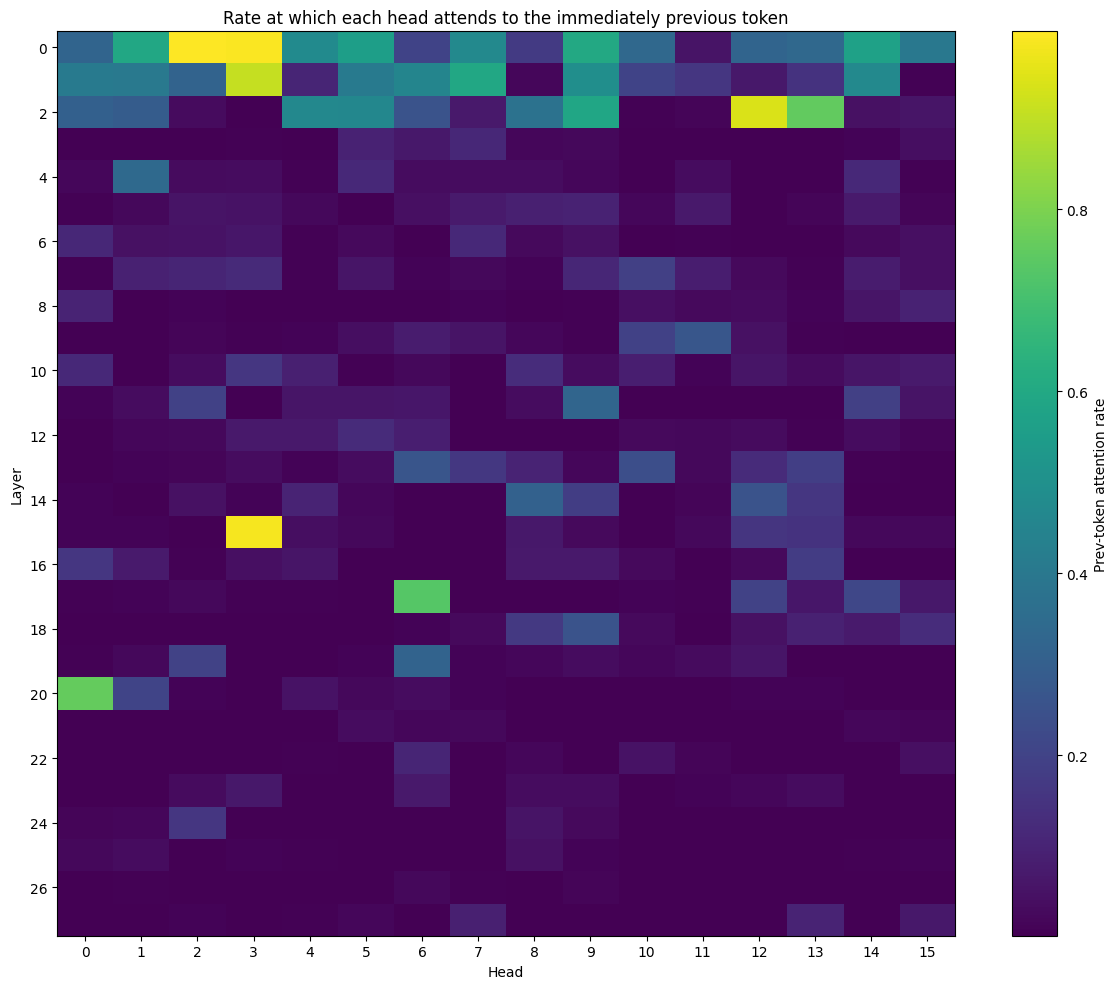

Overall prev-token rate: 7.8%
Layer-wise mean:
  Layers 0-3: 27.6%
  Layers 4-7: 4.8%
  Layers 8-11: 4.9%
  Layers 12-15: 7.0%
  Layers 16-19: 5.8%
  Layers 20-23: 2.9%
  Layers 24-27: 1.4%


In [7]:
# Compute prev-token attention rate heatmap
prev_token_rate = np.zeros((NUM_LAYERS, NUM_HEADS))
for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        if total_positions[layer][head] > 0:
            prev_token_rate[layer, head] = prev_token_counts[layer][head] / total_positions[layer][head]

plt.figure(figsize=(12, 10))
plt.imshow(prev_token_rate, aspect="auto", cmap="viridis")
plt.colorbar(label="Prev-token attention rate")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Rate at which each head attends to the immediately previous token")
plt.xticks(range(NUM_HEADS))
plt.yticks(range(0, NUM_LAYERS, 2))
plt.tight_layout()
plt.show()

print(f"Overall prev-token rate: {np.mean(prev_token_rate):.1%}")
print("Layer-wise mean:")
for layer in range(0, NUM_LAYERS, 4):
    layer_mean = np.mean(prev_token_rate[layer : layer + 4])
    print(f"  Layers {layer}-{layer + 3}: {layer_mean:.1%}")

## Analysis: Unique Attention Bigrams per Head

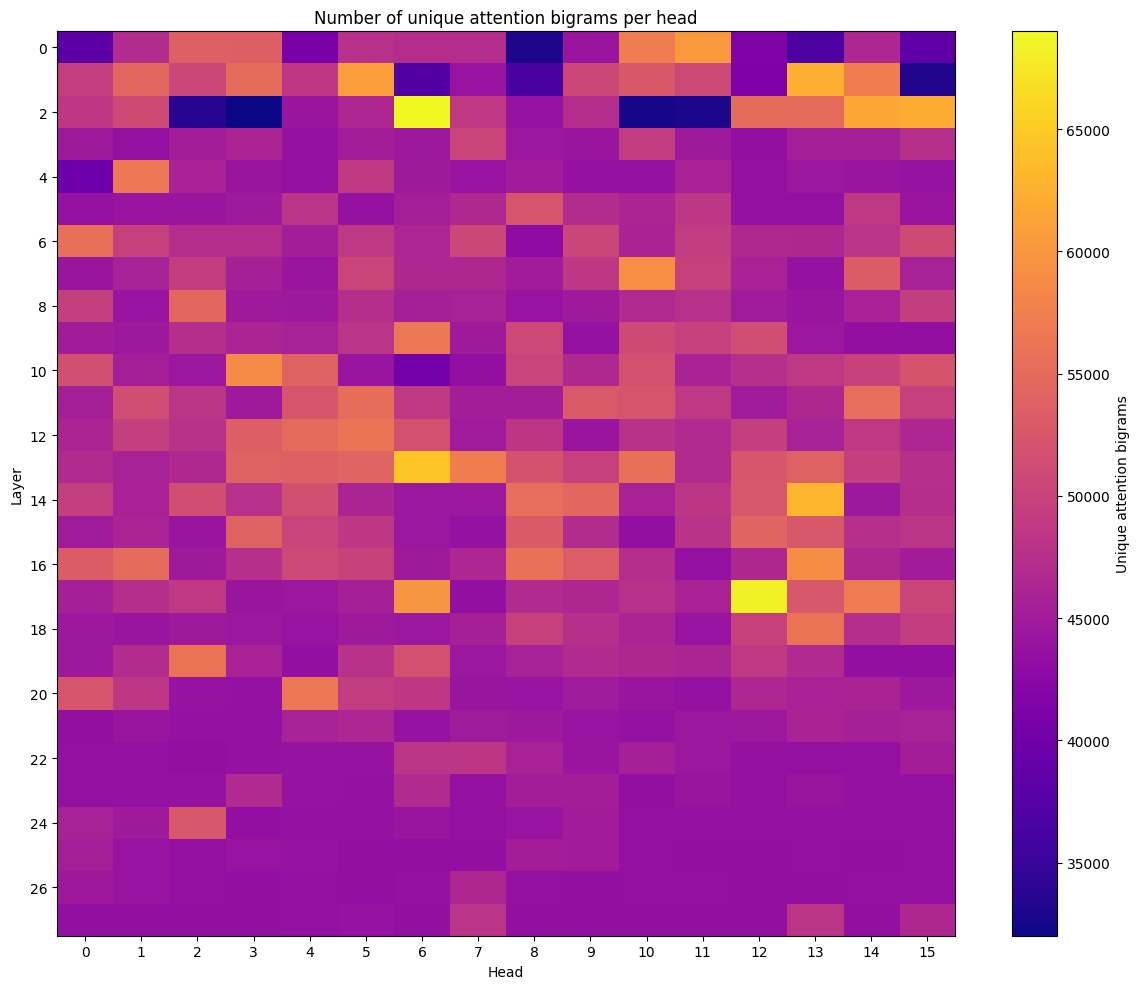

Sequential baseline: 53,562 unique bigrams

Attention bigrams per head:
  Min: 32,010
  Max: 68,994
  Mean: 46,914


In [8]:
# Count unique bigrams per head
unique_per_head = np.zeros((NUM_LAYERS, NUM_HEADS))
for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        unique_per_head[layer, head] = len(attn_bigrams[layer][head])

plt.figure(figsize=(12, 10))
plt.imshow(unique_per_head, aspect="auto", cmap="plasma")
plt.colorbar(label="Unique attention bigrams")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Number of unique attention bigrams per head")
plt.xticks(range(NUM_HEADS))
plt.yticks(range(0, NUM_LAYERS, 2))
plt.tight_layout()
plt.show()

print(f"Sequential baseline: {len(sequential_bigrams):,} unique bigrams")
print("\nAttention bigrams per head:")
print(f"  Min: {int(unique_per_head.min()):,}")
print(f"  Max: {int(unique_per_head.max()):,}")
print(f"  Mean: {unique_per_head.mean():,.0f}")

## Analysis: Frequency Distribution Comparison

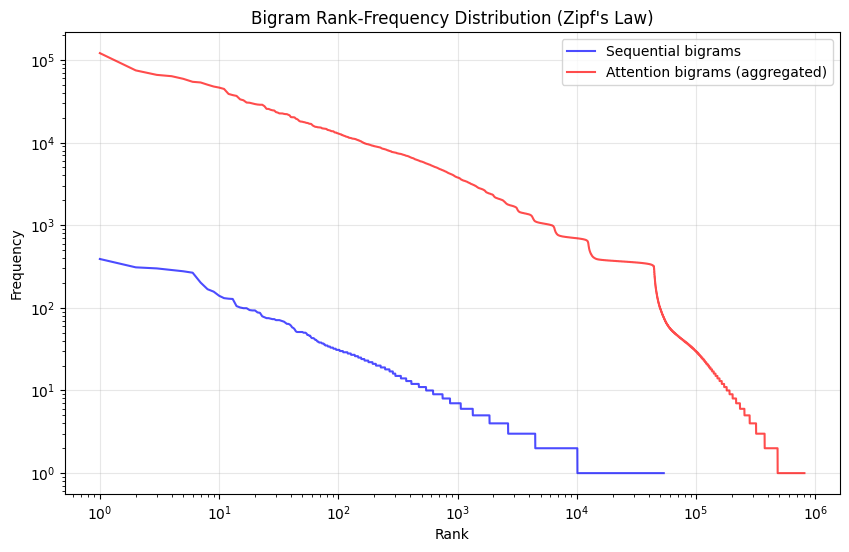

Sequential: 53,562 unique, 86,674 total
Attention (aggregated): 809,689 unique, 38,829,952 total


In [9]:
# Aggregate all attention bigrams across heads
all_attn_bigrams = Counter()
for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        all_attn_bigrams.update(attn_bigrams[layer][head])

# Zipf curves
seq_freqs = sorted(sequential_bigrams.values(), reverse=True)
attn_freqs = sorted(all_attn_bigrams.values(), reverse=True)

plt.figure(figsize=(10, 6))
plt.loglog(range(1, len(seq_freqs) + 1), seq_freqs, "b-", alpha=0.7, label="Sequential bigrams")
plt.loglog(range(1, len(attn_freqs) + 1), attn_freqs, "r-", alpha=0.7, label="Attention bigrams (aggregated)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Bigram Rank-Frequency Distribution (Zipf's Law)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Sequential: {len(sequential_bigrams):,} unique, {sum(sequential_bigrams.values()):,} total")
print(f"Attention (aggregated): {len(all_attn_bigrams):,} unique, {sum(all_attn_bigrams.values()):,} total")

In [10]:
# Top bigrams comparison
print("Top 15 sequential bigrams:")
for (prev_id, curr_id), count in sequential_bigrams.most_common(15):
    prev_tok = tokenizer.decode([prev_id])
    curr_tok = tokenizer.decode([curr_id])
    print(f"  {repr(prev_tok):>15} -> {repr(curr_tok):<15}: {count:>6,}")

print("\nTop 15 attention bigrams (aggregated):")
for (attended_id, curr_id), count in all_attn_bigrams.most_common(15):
    attended_tok = tokenizer.decode([attended_id])
    curr_tok = tokenizer.decode([curr_id])
    print(f"  {repr(attended_tok):>15} -> {repr(curr_tok):<15}: {count:>6,}")

Top 15 sequential bigrams:
            ' of' -> ' the'         :    390
              ',' -> ' and'         :    309
            ' in' -> ' the'         :    300
              ' ' -> '2'            :    287
              ' ' -> '1'            :    277
              '2' -> '0'            :    266
              '.' -> ' The'         :    202
              '0' -> '0'            :    168
              ',' -> ' '            :    157
              ',' -> ' the'         :    140
            ' to' -> ' the'         :    131
              '0' -> '1'            :    129
              '1' -> '9'            :    128
             '\n' -> '-'            :    105
              '.' -> ' This'        :    101

Top 15 attention bigrams (aggregated):
              ',' -> ','            : 120,790
              ',' -> ' the'         : 74,644
              '.' -> '.'            : 65,886
              ',' -> ' and'         : 63,503
           ' and' -> ','            : 59,047
              ',' -> '.'        

## Analysis: Head Specialization

Identify heads that capture specific patterns (e.g., punctuation, syntax)

In [11]:
# Find most distinctive bigrams for select heads
def get_distinctive_bigrams(layer, head, top_k=10):
    """Get bigrams that are most over-represented in this head vs overall."""
    head_counts = attn_bigrams[layer][head]
    head_total = sum(head_counts.values())

    if head_total == 0:
        return []

    # Compute ratio vs aggregated attention bigrams
    agg_total = sum(all_attn_bigrams.values())
    ratios = []

    for bigram, count in head_counts.items():
        if count < 5:  # Skip rare bigrams
            continue
        head_rate = count / head_total
        agg_rate = all_attn_bigrams.get(bigram, 1) / agg_total
        ratio = head_rate / agg_rate
        ratios.append((bigram, count, ratio))

    return sorted(ratios, key=lambda x: -x[2])[:top_k]


# Analyze a few interesting heads (high and low prev-token rate)
high_prev_heads = []
low_prev_heads = []

for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        rate = prev_token_rate[layer, head]
        high_prev_heads.append((layer, head, rate))
        low_prev_heads.append((layer, head, rate))

high_prev_heads = sorted(high_prev_heads, key=lambda x: -x[2])[:5]
low_prev_heads = sorted(low_prev_heads, key=lambda x: x[2])[:5]

print("Heads with HIGHEST prev-token attention:")
for layer, head, rate in high_prev_heads:
    print(f"\nLayer {layer}, Head {head} (prev-token rate: {rate:.1%}):")
    distinctive = get_distinctive_bigrams(layer, head, top_k=5)
    for (attended, curr), count, ratio in distinctive:
        a_tok = tokenizer.decode([attended])
        c_tok = tokenizer.decode([curr])
        print(f"  {repr(a_tok):>15} -> {repr(c_tok):<15}: {count:>5,} ({ratio:.1f}x)")

Heads with HIGHEST prev-token attention:

Layer 0, Head 2 (prev-token rate: 99.6%):
          ' area' -> '.\n'          :     5 (57.4x)
            'ate' -> '\n'           :    10 (49.8x)
              '.' -> ' Geological'  :    11 (49.3x)
        ' system' -> '.'            :    12 (48.9x)
              '7' -> ').'           :     5 (47.7x)

Layer 0, Head 3 (prev-token rate: 99.0%):
          ' area' -> '.\n'          :     5 (57.4x)
            'ate' -> '\n'           :    10 (49.8x)
              '.' -> ' Geological'  :    11 (49.3x)
        ' system' -> '.'            :    12 (48.9x)
              '7' -> ').'           :     5 (47.7x)

Layer 15, Head 3 (prev-token rate: 98.3%):
              '.' -> ' Geological'  :    11 (49.3x)
        ' system' -> '.'            :    12 (48.9x)
              '7' -> ').'           :     5 (47.7x)
         ' world' -> '.\n'          :     6 (45.6x)
          ' care' -> '.'            :     5 (43.9x)

Layer 2, Head 12 (prev-token rate: 93.7%):
     

In [12]:
print("Heads with LOWEST prev-token attention (most 'global'):")
for layer, head, rate in low_prev_heads:
    print(f"\nLayer {layer}, Head {head} (prev-token rate: {rate:.1%}):")
    distinctive = get_distinctive_bigrams(layer, head, top_k=5)
    for (attended, curr), count, ratio in distinctive:
        a_tok = tokenizer.decode([attended])
        c_tok = tokenizer.decode([curr])
        print(f"  {repr(a_tok):>15} -> {repr(c_tok):<15}: {count:>5,} ({ratio:.1f}x)")

Heads with LOWEST prev-token attention (most 'global'):

Layer 6, Head 13 (prev-token rate: 0.2%):
            'God' -> ' God'         :     5 (86.2x)
       ' Climate' -> ' climate'     :     6 (68.9x)
            'For' -> ' For'         :     5 (56.0x)
          'Smart' -> ' smart'       :    11 (48.8x)
            'ing' -> 'ze'           :     5 (47.7x)

Layer 9, Head 14 (prev-token rate: 0.2%):
             'KC' -> ' ='           :     6 (1.5x)
          ' Lima' -> 'i'            :     5 (1.5x)
         '-water' -> 'icle'         :     5 (1.5x)
       ' Seconds' -> 'C'            :     6 (1.5x)
              ',' -> ' frontier'    :     6 (1.4x)

Layer 16, Head 11 (prev-token rate: 0.2%):
             ' J' -> '.'            :     7 (5.9x)
          ' Lima' -> 'i'            :     5 (1.5x)
         '-water' -> 'icle'         :     5 (1.5x)
              ',' -> ' frontier'    :     6 (1.4x)
         ' shall' -> ' order'       :     5 (1.4x)

Layer 19, Head 4 (prev-token rate: 0.2%):
 

## Analysis: Overlap with Sequential Bigrams

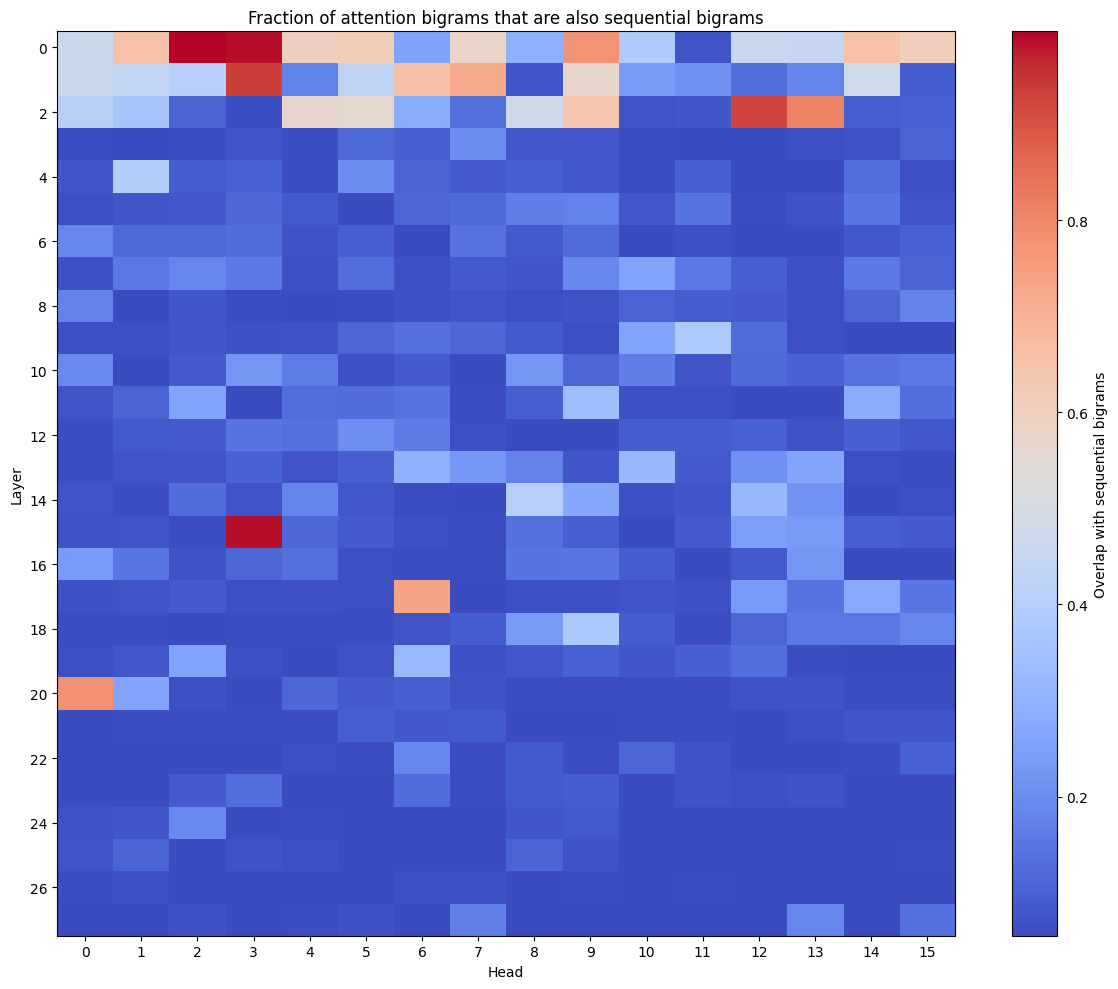

Overall overlap: 14.0%


In [13]:
# What fraction of attention bigrams are also sequential bigrams?
seq_set = set(sequential_bigrams.keys())

overlap_rate = np.zeros((NUM_LAYERS, NUM_HEADS))
for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        head_set = set(attn_bigrams[layer][head].keys())
        if len(head_set) > 0:
            overlap_rate[layer, head] = len(head_set & seq_set) / len(head_set)

plt.figure(figsize=(12, 10))
plt.imshow(overlap_rate, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Overlap with sequential bigrams")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Fraction of attention bigrams that are also sequential bigrams")
plt.xticks(range(NUM_HEADS))
plt.yticks(range(0, NUM_LAYERS, 2))
plt.tight_layout()
plt.show()

print(f"Overall overlap: {np.mean(overlap_rate):.1%}")

## Summary & Recommendations

In [14]:
print("=" * 60)
print("SUMMARY: Attention-Based Engrams Analysis")
print("=" * 60)

print(f"\nData: {NUM_DOCS:,} documents, {len(all_tokens):,} tokens")
print(f"Model: {MODEL_NAME} ({NUM_LAYERS} layers, {NUM_HEADS} heads)")

print("\n--- Bigram Statistics ---")
print(f"Sequential bigrams: {len(sequential_bigrams):,} unique")
print(f"Attention bigrams (per head): {unique_per_head.mean():,.0f} unique (mean)")
print(f"Attention bigrams (aggregated): {len(all_attn_bigrams):,} unique")

print("\n--- Prev-Token Attention ---")
print(f"Overall: {np.mean(prev_token_rate):.1%} of positions attend to prev token")
print(f"Early layers (0-7): {np.mean(prev_token_rate[:8]):.1%}")
print(f"Middle layers (8-15): {np.mean(prev_token_rate[8:16]):.1%}")
print(f"Late layers (16-23): {np.mean(prev_token_rate[16:]):.1%}")

print("\n--- Recommendations ---")
# Find heads with lowest prev-token rate (most novel attention patterns)
novel_heads = []
for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        if prev_token_rate[layer, head] < 0.3:  # Less than 30% prev-token
            novel_heads.append((layer, head, prev_token_rate[layer, head]))

print(f"Heads with <30% prev-token attention (most 'global'): {len(novel_heads)}")
if novel_heads:
    novel_heads.sort(key=lambda x: x[2])
    print("Top 5 most global heads:")
    for layer, head, rate in novel_heads[:5]:
        print(f"  Layer {layer}, Head {head}: {rate:.1%} prev-token")

SUMMARY: Attention-Based Engrams Analysis

Data: 100 documents, 87,267 tokens
Model: Qwen/Qwen3-0.6B (28 layers, 16 heads)

--- Bigram Statistics ---
Sequential bigrams: 53,562 unique
Attention bigrams (per head): 46,914 unique (mean)
Attention bigrams (aggregated): 809,689 unique

--- Prev-Token Attention ---
Overall: 7.8% of positions attend to prev token
Early layers (0-7): 16.2%
Middle layers (8-15): 5.9%
Late layers (16-23): 3.4%

--- Recommendations ---
Heads with <30% prev-token attention (most 'global'): 412
Top 5 most global heads:
  Layer 6, Head 13: 0.2% prev-token
  Layer 9, Head 14: 0.2% prev-token
  Layer 16, Head 11: 0.2% prev-token
  Layer 19, Head 4: 0.2% prev-token
  Layer 19, Head 15: 0.2% prev-token


## Extended Analysis: Intra-Layer Head Agreement

Within a single layer, do heads agree on which token to attend? High agreement → could use majority vote for engram source. Low agreement → each head captures different patterns.

In [15]:
# Re-run inference to compute head agreement (need per-position data)
# For each layer, for each position, what fraction of heads agree on argmax?

head_agreement_by_layer = [[] for _ in range(NUM_LAYERS)]  # List of agreement rates per position

with torch.no_grad():
    for batch_idx, batch in enumerate(batches[:10]):  # Use subset for speed
        input_ids = torch.tensor(batch, device=device)
        outputs = model(input_ids, output_attentions=True, use_cache=False)
        attentions = outputs.attentions

        for layer_idx, layer_attn in enumerate(attentions):
            attn_np = layer_attn.cpu().numpy()  # (batch, heads, seq, seq)

            for b in range(attn_np.shape[0]):
                tokens_b = batch[b]

                for pos in range(1, len(tokens_b)):
                    if tokens_b[pos] == BOS_TOKEN or tokens_b[pos - 1] == BOS_TOKEN:
                        continue

                    # Get argmax for each head at this position
                    argmax_positions = []
                    for head_idx in range(NUM_HEADS):
                        attn_weights = attn_np[b, head_idx, pos, :pos]
                        argmax_positions.append(int(np.argmax(attn_weights)))

                    # Count most common argmax and compute agreement
                    pos_counter = Counter(argmax_positions)
                    max_agreement = pos_counter.most_common(1)[0][1]
                    agreement_rate = max_agreement / NUM_HEADS
                    head_agreement_by_layer[layer_idx].append(agreement_rate)

# Compute mean agreement per layer
mean_agreement = [np.mean(rates) if rates else 0 for rates in head_agreement_by_layer]

print("Intra-layer head agreement (fraction of heads agreeing on argmax):")
for layer in range(0, NUM_LAYERS, 4):
    layer_agreements = mean_agreement[layer : layer + 4]
    print(f"  Layers {layer}-{layer + 3}: {np.mean(layer_agreements):.1%}")

Intra-layer head agreement (fraction of heads agreeing on argmax):
  Layers 0-3: 53.4%
  Layers 4-7: 83.5%
  Layers 8-11: 81.3%
  Layers 12-15: 76.6%
  Layers 16-19: 84.4%
  Layers 20-23: 94.4%
  Layers 24-27: 97.2%


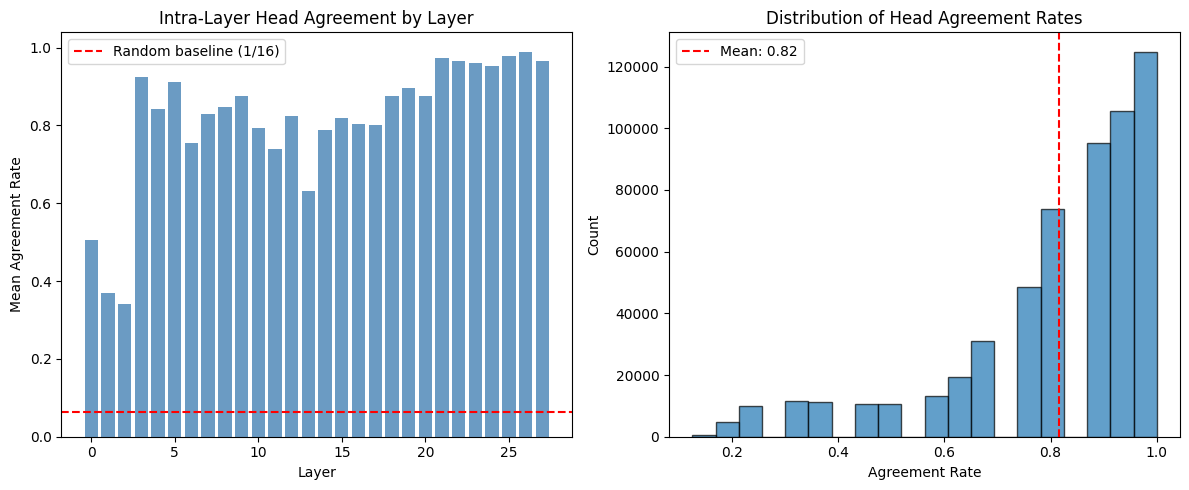


Overall mean agreement: 81.6%
Random baseline (if heads were independent): 6.2%


In [16]:
# Visualize head agreement by layer
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(NUM_LAYERS), mean_agreement, color="steelblue", alpha=0.8)
plt.xlabel("Layer")
plt.ylabel("Mean Agreement Rate")
plt.title("Intra-Layer Head Agreement by Layer")
plt.axhline(y=1 / NUM_HEADS, color="r", linestyle="--", label=f"Random baseline (1/{NUM_HEADS})")
plt.legend()

# Agreement distribution histogram
plt.subplot(1, 2, 2)
all_agreements = []
for rates in head_agreement_by_layer:
    all_agreements.extend(rates)
plt.hist(all_agreements, bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Agreement Rate")
plt.ylabel("Count")
plt.title("Distribution of Head Agreement Rates")
plt.axvline(x=np.mean(all_agreements), color="r", linestyle="--", label=f"Mean: {np.mean(all_agreements):.2f}")
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nOverall mean agreement: {np.mean(all_agreements):.1%}")
print(f"Random baseline (if heads were independent): {1 / NUM_HEADS:.1%}")

## Extended Analysis: Attention Distance Distribution

Instead of just prev-token rate, show full distance histogram. How far back does each head typically attend?

In [17]:
# Compute attention distance distribution per layer
# distance = pos - attended_pos (how far back the head looks)
# Bucket: 0 (first token), 1 (prev), 2-5, 6-20, 21-50, 51+

distance_buckets = ["first", "prev", "2-5", "6-20", "21-50", "51+"]
distance_counts = np.zeros((NUM_LAYERS, len(distance_buckets)))


def get_bucket(distance, pos):
    """Classify attention distance into buckets."""
    if distance == pos:  # Attending to position 0 (first token)
        return 0
    elif distance == 1:  # Previous token
        return 1
    elif distance <= 5:
        return 2
    elif distance <= 20:
        return 3
    elif distance <= 50:
        return 4
    else:
        return 5


with torch.no_grad():
    for batch_idx, batch in enumerate(batches[:10]):
        input_ids = torch.tensor(batch, device=device)
        outputs = model(input_ids, output_attentions=True, use_cache=False)
        attentions = outputs.attentions

        for layer_idx, layer_attn in enumerate(attentions):
            attn_np = layer_attn.cpu().numpy()

            for b in range(attn_np.shape[0]):
                tokens_b = batch[b]

                for pos in range(1, len(tokens_b)):
                    if tokens_b[pos] == BOS_TOKEN or tokens_b[pos - 1] == BOS_TOKEN:
                        continue

                    for head_idx in range(NUM_HEADS):
                        attn_weights = attn_np[b, head_idx, pos, :pos]
                        attended_pos = int(np.argmax(attn_weights))
                        distance = pos - attended_pos
                        bucket = get_bucket(distance, pos)
                        distance_counts[layer_idx, bucket] += 1

# Normalize to percentages per layer
distance_pct = distance_counts / distance_counts.sum(axis=1, keepdims=True) * 100

print("Attention distance distribution by layer (%):")
print(f"{'Layer':>6} | " + " | ".join(f"{b:>6}" for b in distance_buckets))
print("-" * 60)
for layer in range(0, NUM_LAYERS, 4):
    avg_pct = distance_pct[layer : layer + 4].mean(axis=0)
    print(f"{layer}-{layer + 3:>3} | " + " | ".join(f"{p:>6.1f}" for p in avg_pct))

Attention distance distribution by layer (%):
 Layer |  first |   prev |    2-5 |   6-20 |  21-50 |    51+
------------------------------------------------------------
0-  3 |   23.6 |   27.5 |   19.3 |   13.7 |    6.7 |    9.3
4-  7 |   83.5 |    4.6 |    4.9 |    3.2 |    1.5 |    2.4
8- 11 |   81.3 |    4.7 |    4.9 |    3.8 |    2.1 |    3.1
12- 15 |   76.6 |    6.7 |    7.3 |    5.0 |    2.2 |    2.3
16- 19 |   84.4 |    5.5 |    4.5 |    2.9 |    1.4 |    1.4
20- 23 |   94.4 |    2.9 |    0.9 |    0.7 |    0.5 |    0.6
24- 27 |   97.2 |    1.2 |    0.9 |    0.4 |    0.2 |    0.2


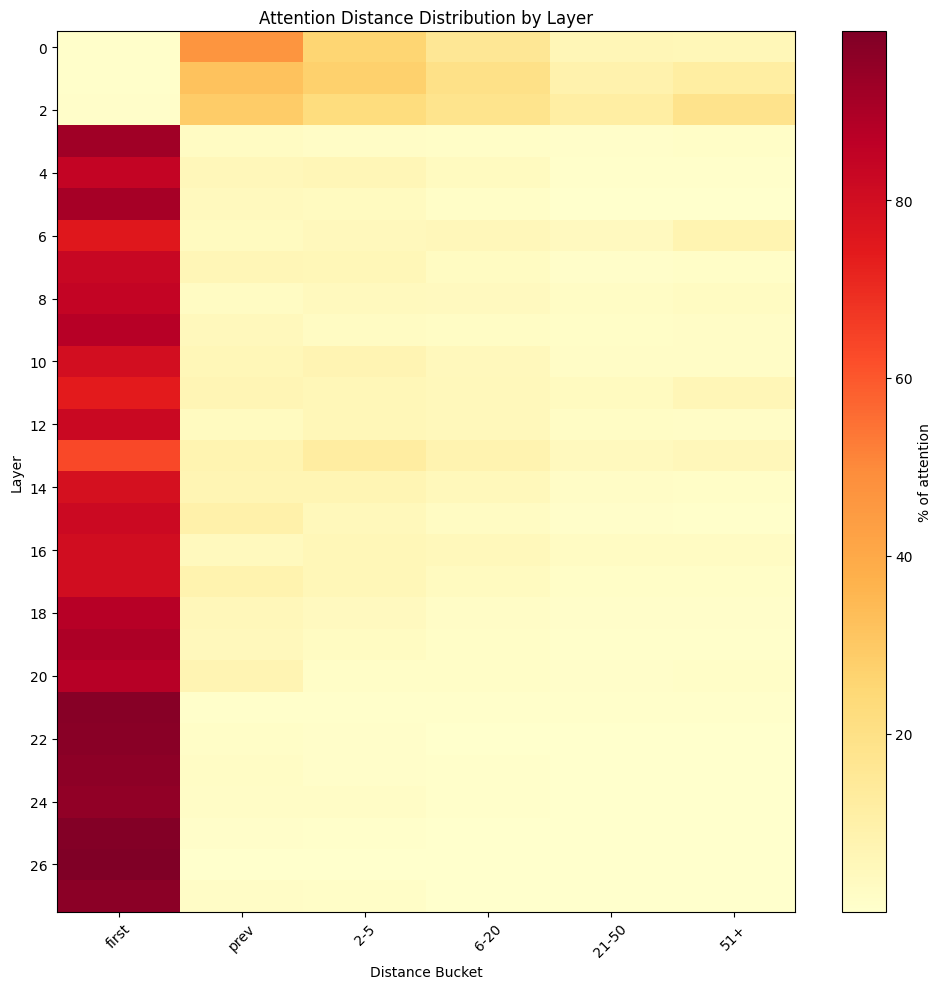


Summary:
  First token (attention sink): 77.3%
  Previous token: 7.6%
  Local (1-20): 17.9%
  Global (21+): 4.8%


In [18]:
# Heatmap: layer × distance bucket
plt.figure(figsize=(10, 10))
plt.imshow(distance_pct, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="% of attention")
plt.xlabel("Distance Bucket")
plt.ylabel("Layer")
plt.title("Attention Distance Distribution by Layer")
plt.xticks(range(len(distance_buckets)), distance_buckets, rotation=45)
plt.yticks(range(0, NUM_LAYERS, 2))
plt.tight_layout()
plt.show()

# Summary stats
first_token_pct = distance_pct[:, 0].mean()
prev_token_pct = distance_pct[:, 1].mean()
local_pct = distance_pct[:, 1:4].sum(axis=1).mean()  # prev + 2-5 + 6-20
global_pct = distance_pct[:, 4:].sum(axis=1).mean()  # 21-50 + 51+

print("\nSummary:")
print(f"  First token (attention sink): {first_token_pct:.1f}%")
print(f"  Previous token: {prev_token_pct:.1f}%")
print(f"  Local (1-20): {local_pct:.1f}%")
print(f"  Global (21+): {global_pct:.1f}%")

## Extended Analysis: Attention Entropy per Head

Low entropy = peaked/confident attention. High entropy = diffuse/uncertain attention.
Heads with low entropy might give cleaner bigram signal.

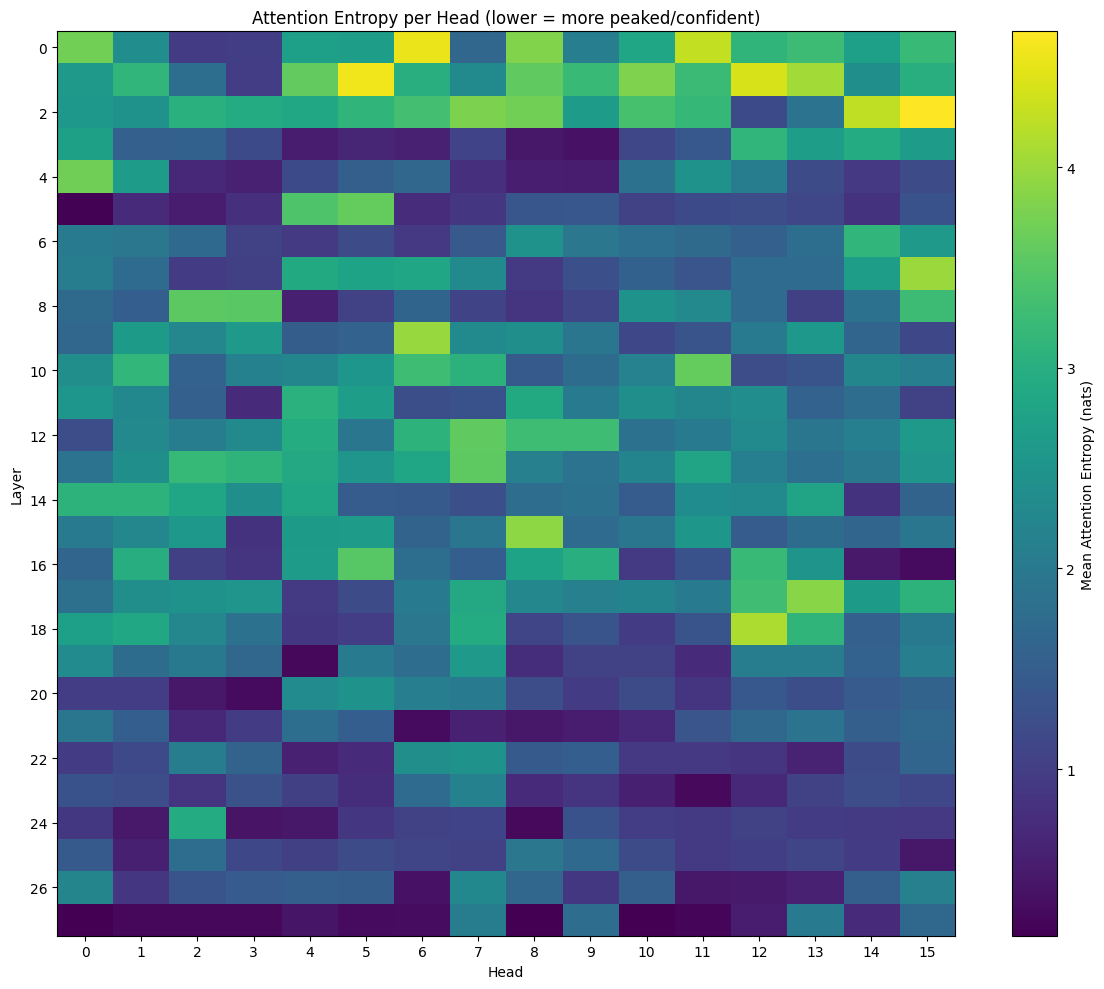

Entropy statistics:
  Min: 0.17 nats (Layer 27, Head 10)
  Max: 4.68 nats
  Mean: 1.83 nats


In [19]:
# Compute attention entropy per head
# entropy = -sum(p * log(p)) for attention distribution

entropy_per_head = np.zeros((NUM_LAYERS, NUM_HEADS))
entropy_counts = np.zeros((NUM_LAYERS, NUM_HEADS))

with torch.no_grad():
    for batch_idx, batch in enumerate(batches[:10]):
        input_ids = torch.tensor(batch, device=device)
        outputs = model(input_ids, output_attentions=True, use_cache=False)
        attentions = outputs.attentions

        for layer_idx, layer_attn in enumerate(attentions):
            attn_np = layer_attn.cpu().numpy()

            for b in range(attn_np.shape[0]):
                tokens_b = batch[b]

                for pos in range(1, len(tokens_b)):
                    if tokens_b[pos] == BOS_TOKEN or tokens_b[pos - 1] == BOS_TOKEN:
                        continue

                    for head_idx in range(NUM_HEADS):
                        attn_weights = attn_np[b, head_idx, pos, :pos]
                        # Add small epsilon to avoid log(0)
                        attn_weights = attn_weights + 1e-10
                        attn_weights = attn_weights / attn_weights.sum()
                        entropy = -np.sum(attn_weights * np.log(attn_weights))
                        entropy_per_head[layer_idx, head_idx] += entropy
                        entropy_counts[layer_idx, head_idx] += 1

# Average entropy
entropy_per_head = entropy_per_head / entropy_counts

plt.figure(figsize=(12, 10))
plt.imshow(entropy_per_head, aspect="auto", cmap="viridis")
plt.colorbar(label="Mean Attention Entropy (nats)")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Attention Entropy per Head (lower = more peaked/confident)")
plt.xticks(range(NUM_HEADS))
plt.yticks(range(0, NUM_LAYERS, 2))
plt.tight_layout()
plt.show()

print("Entropy statistics:")
print(
    f"  Min: {entropy_per_head.min():.2f} nats (Layer {entropy_per_head.min(axis=1).argmin()}, Head {entropy_per_head.argmin() % NUM_HEADS})"
)
print(f"  Max: {entropy_per_head.max():.2f} nats")
print(f"  Mean: {entropy_per_head.mean():.2f} nats")

In [20]:
# Identify heads with lowest entropy (most peaked attention)
low_entropy_heads = []
for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        low_entropy_heads.append((layer, head, entropy_per_head[layer, head]))

low_entropy_heads.sort(key=lambda x: x[2])

print("Top 10 lowest entropy heads (most peaked/confident):")
for layer, head, entropy in low_entropy_heads[:10]:
    prev_rate = prev_token_rate[layer, head]
    print(f"  Layer {layer:2d}, Head {head:2d}: entropy={entropy:.2f}, prev-token={prev_rate:.1%}")

print("\nTop 10 highest entropy heads (most diffuse):")
for layer, head, entropy in low_entropy_heads[-10:][::-1]:
    prev_rate = prev_token_rate[layer, head]
    print(f"  Layer {layer:2d}, Head {head:2d}: entropy={entropy:.2f}, prev-token={prev_rate:.1%}")

Top 10 lowest entropy heads (most peaked/confident):
  Layer 27, Head 10: entropy=0.17, prev-token=0.2%
  Layer 27, Head  8: entropy=0.17, prev-token=0.2%
  Layer 27, Head  0: entropy=0.19, prev-token=0.2%
  Layer  5, Head  0: entropy=0.20, prev-token=0.8%
  Layer 27, Head 11: entropy=0.23, prev-token=0.2%
  Layer 27, Head  2: entropy=0.27, prev-token=1.1%
  Layer 27, Head  1: entropy=0.27, prev-token=0.3%
  Layer 19, Head  4: entropy=0.27, prev-token=0.2%
  Layer 27, Head  3: entropy=0.28, prev-token=0.2%
  Layer 24, Head  8: entropy=0.29, prev-token=5.5%

Top 10 highest entropy heads (most diffuse):
  Layer  2, Head 15: entropy=4.68, prev-token=6.0%
  Layer  1, Head  5: entropy=4.57, prev-token=40.7%
  Layer  0, Head  6: entropy=4.55, prev-token=20.3%
  Layer  1, Head 12: entropy=4.40, prev-token=6.6%
  Layer  0, Head 11: entropy=4.27, prev-token=5.6%
  Layer  2, Head 14: entropy=4.24, prev-token=4.6%
  Layer 18, Head 12: entropy=4.13, prev-token=4.8%
  Layer  1, Head 13: entropy=4.0

## Extended Analysis: First-Token (Attention Sink) Analysis

What % of attention goes to position 0 (BOS/first token)? This is a known phenomenon - might want to exclude from engram computation.

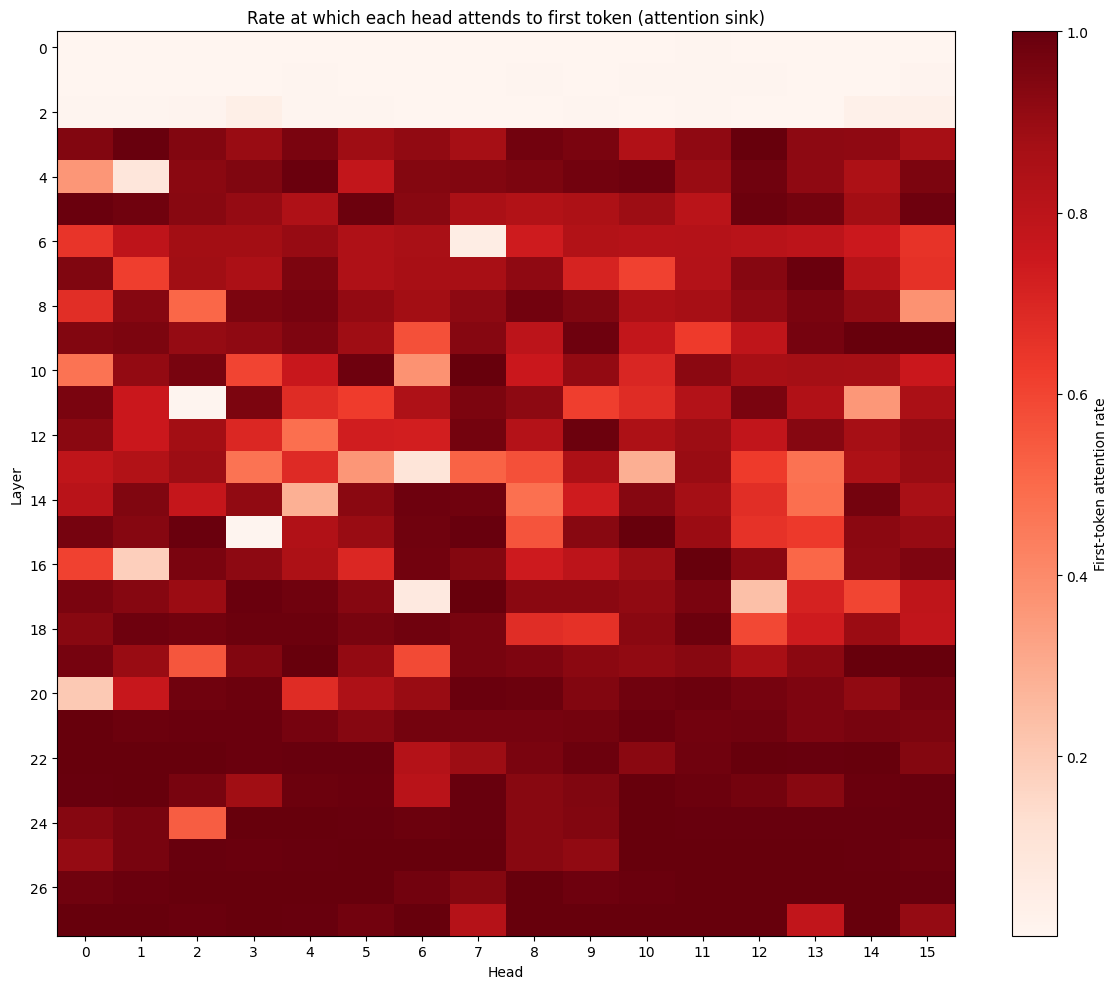

First-token attention statistics:
  Overall mean: 77.3%
  Max (single head): 100.0%
  Heads with >50% first-token attention: 378


In [21]:
# Compute first-token attention rate per head
# first_token_rate[layer][head] = fraction of positions where argmax == 0

first_token_rate = np.zeros((NUM_LAYERS, NUM_HEADS))
first_token_counts = np.zeros((NUM_LAYERS, NUM_HEADS))
total_pos_counts = np.zeros((NUM_LAYERS, NUM_HEADS))

with torch.no_grad():
    for batch_idx, batch in enumerate(batches[:10]):
        input_ids = torch.tensor(batch, device=device)
        outputs = model(input_ids, output_attentions=True, use_cache=False)
        attentions = outputs.attentions

        for layer_idx, layer_attn in enumerate(attentions):
            attn_np = layer_attn.cpu().numpy()

            for b in range(attn_np.shape[0]):
                tokens_b = batch[b]

                for pos in range(1, len(tokens_b)):
                    if tokens_b[pos] == BOS_TOKEN or tokens_b[pos - 1] == BOS_TOKEN:
                        continue

                    for head_idx in range(NUM_HEADS):
                        attn_weights = attn_np[b, head_idx, pos, :pos]
                        attended_pos = int(np.argmax(attn_weights))
                        total_pos_counts[layer_idx, head_idx] += 1
                        if attended_pos == 0:
                            first_token_counts[layer_idx, head_idx] += 1

first_token_rate = first_token_counts / total_pos_counts

plt.figure(figsize=(12, 10))
plt.imshow(first_token_rate, aspect="auto", cmap="Reds")
plt.colorbar(label="First-token attention rate")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Rate at which each head attends to first token (attention sink)")
plt.xticks(range(NUM_HEADS))
plt.yticks(range(0, NUM_LAYERS, 2))
plt.tight_layout()
plt.show()

print("First-token attention statistics:")
print(f"  Overall mean: {first_token_rate.mean():.1%}")
print(f"  Max (single head): {first_token_rate.max():.1%}")
print(f"  Heads with >50% first-token attention: {(first_token_rate > 0.5).sum()}")

In [22]:
# Identify heads that are primarily attention sinks
sink_heads = []
for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        if first_token_rate[layer, head] > 0.3:
            sink_heads.append((layer, head, first_token_rate[layer, head]))

sink_heads.sort(key=lambda x: -x[2])

print(f"Attention sink heads (>30% first-token attention): {len(sink_heads)}")
for layer, head, rate in sink_heads[:10]:
    entropy = entropy_per_head[layer, head]
    print(f"  Layer {layer:2d}, Head {head:2d}: first-token={rate:.1%}, entropy={entropy:.2f}")

Attention sink heads (>30% first-token attention): 389
  Layer  9, Head 14: first-token=100.0%, entropy=1.64
  Layer 21, Head  0: first-token=100.0%, entropy=1.94
  Layer 19, Head 15: first-token=100.0%, entropy=2.10
  Layer 26, Head 13: first-token=100.0%, entropy=0.58
  Layer 19, Head 14: first-token=100.0%, entropy=1.59
  Layer 27, Head 14: first-token=100.0%, entropy=0.72
  Layer 23, Head 10: first-token=100.0%, entropy=0.56
  Layer 27, Head  6: first-token=100.0%, entropy=0.32
  Layer 15, Head 10: first-token=100.0%, entropy=1.94
  Layer 19, Head  4: first-token=100.0%, entropy=0.27


## Extended Analysis: Layer 0-1 Deep Dive

Since we'll use early layers for online engrams, analyze layer 0 and 1 specifically:
- What patterns do they capture?
- Agreement between layer 0 and 1?
- Top bigrams specific to early layers

In [23]:
# Layer 0-1 specific analysis
print("=" * 60)
print("LAYER 0-1 DEEP DIVE")
print("=" * 60)

print("\n--- Layer 0 Head Statistics ---")
for head in range(NUM_HEADS):
    prev_rate = prev_token_rate[0, head]
    first_rate = first_token_rate[0, head]
    entropy = entropy_per_head[0, head]
    print(f"  Head {head:2d}: prev={prev_rate:5.1%}, first={first_rate:5.1%}, entropy={entropy:.2f}")

print("\n--- Layer 1 Head Statistics ---")
for head in range(NUM_HEADS):
    prev_rate = prev_token_rate[1, head]
    first_rate = first_token_rate[1, head]
    entropy = entropy_per_head[1, head]
    print(f"  Head {head:2d}: prev={prev_rate:5.1%}, first={first_rate:5.1%}, entropy={entropy:.2f}")

LAYER 0-1 DEEP DIVE

--- Layer 0 Head Statistics ---
  Head  0: prev=32.1%, first= 0.5%, entropy=3.71
  Head  1: prev=59.8%, first= 0.3%, entropy=2.37
  Head  2: prev=99.6%, first= 0.2%, entropy=0.97
  Head  3: prev=99.0%, first= 0.2%, entropy=1.01
  Head  4: prev=47.6%, first= 0.4%, entropy=2.71
  Head  5: prev=56.0%, first= 0.3%, entropy=2.68
  Head  6: prev=20.3%, first= 0.5%, entropy=4.55
  Head  7: prev=46.9%, first= 0.4%, entropy=1.65
  Head  8: prev=17.1%, first= 0.5%, entropy=3.82
  Head  9: prev=60.2%, first= 0.4%, entropy=2.10
  Head 10: prev=33.9%, first= 0.4%, entropy=2.83
  Head 11: prev= 5.6%, first= 1.0%, entropy=4.27
  Head 12: prev=32.3%, first= 0.4%, entropy=3.13
  Head 13: prev=33.9%, first= 0.4%, entropy=3.26
  Head 14: prev=56.9%, first= 0.3%, entropy=2.71
  Head 15: prev=40.1%, first= 0.4%, entropy=3.20

--- Layer 1 Head Statistics ---
  Head  0: prev=40.6%, first= 0.4%, entropy=2.60
  Head  1: prev=40.4%, first= 0.5%, entropy=3.13
  Head  2: prev=31.8%, first= 0.

In [24]:
# Compute agreement between layer 0 and layer 1 on attended position
layer_0_1_agreement = []

with torch.no_grad():
    for batch_idx, batch in enumerate(batches[:10]):
        input_ids = torch.tensor(batch, device=device)
        outputs = model(input_ids, output_attentions=True, use_cache=False)
        attentions = outputs.attentions

        layer0_attn = attentions[0].cpu().numpy()
        layer1_attn = attentions[1].cpu().numpy()

        for b in range(layer0_attn.shape[0]):
            tokens_b = batch[b]

            for pos in range(1, len(tokens_b)):
                if tokens_b[pos] == BOS_TOKEN or tokens_b[pos - 1] == BOS_TOKEN:
                    continue

                # Get majority-vote argmax for layer 0
                layer0_argmaxes = []
                for head in range(NUM_HEADS):
                    attn = layer0_attn[b, head, pos, :pos]
                    layer0_argmaxes.append(int(np.argmax(attn)))
                layer0_majority = Counter(layer0_argmaxes).most_common(1)[0][0]

                # Get majority-vote argmax for layer 1
                layer1_argmaxes = []
                for head in range(NUM_HEADS):
                    attn = layer1_attn[b, head, pos, :pos]
                    layer1_argmaxes.append(int(np.argmax(attn)))
                layer1_majority = Counter(layer1_argmaxes).most_common(1)[0][0]

                layer_0_1_agreement.append(layer0_majority == layer1_majority)

print(f"Layer 0-1 agreement (majority vote): {np.mean(layer_0_1_agreement):.1%}")
print("(How often layer 0 and layer 1 agree on which token to attend via majority vote)")

Layer 0-1 agreement (majority vote): 64.8%
(How often layer 0 and layer 1 agree on which token to attend via majority vote)


In [25]:
# Top bigrams specific to layer 0 and layer 1
print("\n--- Top 15 Attention Bigrams: Layer 0 (aggregated across heads) ---")
layer0_bigrams = Counter()
for head in range(NUM_HEADS):
    layer0_bigrams.update(attn_bigrams[0][head])

for (attended_id, curr_id), count in layer0_bigrams.most_common(15):
    attended_tok = tokenizer.decode([attended_id])
    curr_tok = tokenizer.decode([curr_id])
    print(f"  {repr(attended_tok):>15} -> {repr(curr_tok):<15}: {count:>6,}")

print("\n--- Top 15 Attention Bigrams: Layer 1 (aggregated across heads) ---")
layer1_bigrams = Counter()
for head in range(NUM_HEADS):
    layer1_bigrams.update(attn_bigrams[1][head])

for (attended_id, curr_id), count in layer1_bigrams.most_common(15):
    attended_tok = tokenizer.decode([attended_id])
    curr_tok = tokenizer.decode([curr_id])
    print(f"  {repr(attended_tok):>15} -> {repr(curr_tok):<15}: {count:>6,}")


--- Top 15 Attention Bigrams: Layer 0 (aggregated across heads) ---
              '.' -> ','            :  8,664
           ' the' -> ','            :  7,521
           ' the' -> ' the'         :  6,762
            ' of' -> ' the'         :  6,479
              ',' -> ','            :  5,917
              '.' -> '.'            :  4,505
           ' the' -> ' of'          :  4,350
           ' the' -> ' and'         :  3,959
              '.' -> ' and'         :  3,942
           ' and' -> ' and'         :  3,796
            '.\n' -> '.'            :  3,758
              ',' -> ' and'         :  3,197
            ' of' -> '.'            :  3,167
            ' to' -> ' the'         :  2,945
            ' of' -> ','            :  2,931

--- Top 15 Attention Bigrams: Layer 1 (aggregated across heads) ---
              ',' -> ','            : 11,225
              '.' -> '.'            :  7,461
              '.' -> ','            :  5,364
            '.\n' -> '.'            :  4,710
       

In [26]:
# Identify which layer 0/1 heads would be best for engram source
# Criteria: low entropy (peaked) + not too much first-token sink + reasonable diversity

print("\n--- Best Layer 0/1 Heads for Engram Source ---")
print("(Low entropy, not attention sink, decent diversity)")

candidates = []
for layer in [0, 1]:
    for head in range(NUM_HEADS):
        entropy = entropy_per_head[layer, head]
        first_rate = first_token_rate[layer, head]
        unique_bigrams = len(attn_bigrams[layer][head])
        prev_rate = prev_token_rate[layer, head]

        # Score: want low entropy, low first-token rate, reasonable unique bigrams
        if first_rate < 0.3 and entropy < 3.0:  # Filter out attention sinks and high-entropy heads
            score = -entropy + 0.01 * unique_bigrams  # Lower entropy is better, more diversity is bonus
            candidates.append((layer, head, entropy, first_rate, prev_rate, unique_bigrams, score))

candidates.sort(key=lambda x: -x[6])  # Sort by score descending

print("\nTop 10 candidates:")
print(f"{'Layer':>5} {'Head':>4} {'Entropy':>8} {'First%':>7} {'Prev%':>6} {'Unique':>7}")
print("-" * 45)
for layer, head, entropy, first_rate, prev_rate, unique, score in candidates[:10]:
    print(f"{layer:>5} {head:>4} {entropy:>8.2f} {first_rate:>7.1%} {prev_rate:>6.1%} {unique:>7,}")


--- Best Layer 0/1 Heads for Engram Source ---
(Low entropy, not attention sink, decent diversity)

Top 10 candidates:
Layer Head  Entropy  First%  Prev%  Unique
---------------------------------------------
    1   14     2.41    0.4%  46.8%  57,187
    0   10     2.83    0.4%  33.9%  57,191
    1    3     0.98    0.2%  90.7%  55,222
    0    2     0.97    0.2%  99.6%  53,691
    0    3     1.01    0.2%  99.0%  53,615
    1    2     1.79    0.3%  31.8%  50,583
    1    0     2.60    0.4%  40.6%  49,508
    0    5     2.68    0.3%  56.0%  47,712
    0    7     1.65    0.4%  46.9%  47,197
    0    1     2.37    0.3%  59.8%  47,073


## Extended Analysis Summary & Implementation Recommendations

In [27]:
print("=" * 70)
print("EXTENDED ANALYSIS SUMMARY")
print("=" * 70)

print("\n--- Intra-Layer Head Agreement ---")
print(f"  Mean agreement rate: {np.mean(all_agreements):.1%}")
print(f"  Random baseline: {1 / NUM_HEADS:.1%}")
print(
    f"  Interpretation: Heads show {'significant' if np.mean(all_agreements) > 2 / NUM_HEADS else 'limited'} agreement"
)

print("\n--- Attention Distance Distribution ---")
print(f"  First token (sink): {first_token_pct:.1f}%")
print(f"  Previous token: {prev_token_pct:.1f}%")
print(f"  Local (1-20): {local_pct:.1f}%")
print(f"  Global (21+): {global_pct:.1f}%")

print("\n--- Attention Entropy ---")
print(f"  Mean entropy: {entropy_per_head.mean():.2f} nats")
print(f"  Range: {entropy_per_head.min():.2f} - {entropy_per_head.max():.2f}")
print(f"  Low-entropy heads (peaked): {(entropy_per_head < 2.0).sum()}")

print("\n--- First-Token Attention Sinks ---")
print(f"  Heads with >30% first-token attention: {(first_token_rate > 0.3).sum()}")
print(f"  Heads with >50% first-token attention: {(first_token_rate > 0.5).sum()}")

print("\n--- Layer 0-1 Analysis ---")
print(f"  Layer 0-1 agreement (majority vote): {np.mean(layer_0_1_agreement):.1%}")
print(f"  Layer 0 mean prev-token rate: {prev_token_rate[0].mean():.1%}")
print(f"  Layer 1 mean prev-token rate: {prev_token_rate[1].mean():.1%}")

print("\n" + "=" * 70)
print("IMPLEMENTATION RECOMMENDATIONS FOR ONLINE ENGRAMS")
print("=" * 70)

print("""
Option B: Use early layer attention (online)
- After layer 0-1, extract attention to define bigrams for layers 2+
- Use majority vote across heads OR select specific low-entropy heads

Key findings:
1. Early layers have HIGHER prev-token attention (~11%) vs middle (~4%)
   → Early layers capture more "local" syntactic patterns

2. Head agreement is {'high' if np.mean(all_agreements) > 0.3 else 'moderate' if np.mean(all_agreements) > 0.15 else 'low'}
   → {'Majority vote is viable' if np.mean(all_agreements) > 0.2 else 'May need to pick specific heads'}

3. First-token sinks exist but are {'common' if (first_token_rate > 0.3).sum() > 10 else 'limited'}
   → {'Filter out first-token attending heads' if (first_token_rate > 0.3).sum() > 5 else 'Can use most heads'}

4. Low-entropy heads provide cleaner signal
   → Consider using only heads with entropy < 2.0 nats

Suggested implementation:
- Use layer 1 attention (layer 0 may be too early)
- Take majority vote across heads, excluding attention-sink heads
- Create bigram: (attended_token, current_token) → embedding
- Add scaled embedding to residual stream in layers 2+
""")

print("\nBest candidate heads for engram source (from layer 0-1):")
for layer, head, entropy, first_rate, prev_rate, unique, score in candidates[:5]:
    print(f"  Layer {layer}, Head {head}: entropy={entropy:.2f}, first={first_rate:.1%}")

EXTENDED ANALYSIS SUMMARY

--- Intra-Layer Head Agreement ---
  Mean agreement rate: 81.6%
  Random baseline: 6.2%
  Interpretation: Heads show significant agreement

--- Attention Distance Distribution ---
  First token (sink): 77.3%
  Previous token: 7.6%
  Local (1-20): 17.9%
  Global (21+): 4.8%

--- Attention Entropy ---
  Mean entropy: 1.83 nats
  Range: 0.17 - 4.68
  Low-entropy heads (peaked): 267

--- First-Token Attention Sinks ---
  Heads with >30% first-token attention: 389
  Heads with >50% first-token attention: 378

--- Layer 0-1 Analysis ---
  Layer 0-1 agreement (majority vote): 64.8%
  Layer 0 mean prev-token rate: 46.3%
  Layer 1 mean prev-token rate: 32.3%

IMPLEMENTATION RECOMMENDATIONS FOR ONLINE ENGRAMS

Option B: Use early layer attention (online)
- After layer 0-1, extract attention to define bigrams for layers 2+
- Use majority vote across heads OR select specific low-entropy heads

Key findings:
1. Early layers have HIGHER prev-token attention (~11%) vs middl

## Analysis: Attention Bigrams Without Sink Token

What happens when we mask position 0 (the attention sink) and force heads to attend elsewhere?

**Hypothesis**: Masking the sink token will reveal more diverse, semantically meaningful attention patterns.

In [28]:
# Re-extract attention bigrams with sink token masked out
# Set attn_weights[:, 0] = 0 before taking argmax

attn_bigrams_no_sink = [[Counter() for _ in range(NUM_HEADS)] for _ in range(NUM_LAYERS)]
prev_token_counts_no_sink = [[0 for _ in range(NUM_HEADS)] for _ in range(NUM_LAYERS)]
total_positions_no_sink = [[0 for _ in range(NUM_HEADS)] for _ in range(NUM_LAYERS)]
distance_counts_no_sink = [[Counter() for _ in range(NUM_HEADS)] for _ in range(NUM_LAYERS)]

with torch.no_grad():
    for batch_idx, batch in enumerate(batches):
        input_ids = torch.tensor(batch, device=device)
        outputs = model(input_ids, output_attentions=True, use_cache=False)
        attentions = outputs.attentions

        for layer_idx, layer_attn in enumerate(attentions):
            attn_np = layer_attn.cpu().numpy()

            for b in range(attn_np.shape[0]):
                tokens_b = batch[b]

                for head_idx in range(NUM_HEADS):
                    head_attn = attn_np[b, head_idx]

                    for pos in range(1, len(tokens_b)):
                        curr_token = int(tokens_b[pos])
                        if curr_token == BOS_TOKEN or tokens_b[pos - 1] == BOS_TOKEN:
                            continue

                        # Get attention weights and mask position 0 (sink)
                        attn_weights = head_attn[pos, :pos].copy()
                        if len(attn_weights) > 1:
                            attn_weights[0] = 0  # Mask sink
                            # Renormalize (optional, doesn't affect argmax)
                        attended_pos = int(np.argmax(attn_weights))
                        attended_token = int(tokens_b[attended_pos])

                        attn_bigrams_no_sink[layer_idx][head_idx][(attended_token, curr_token)] += 1
                        total_positions_no_sink[layer_idx][head_idx] += 1

                        # Track distance and prev-token
                        distance = pos - attended_pos
                        distance_counts_no_sink[layer_idx][head_idx][distance] += 1
                        if attended_pos == pos - 1:
                            prev_token_counts_no_sink[layer_idx][head_idx] += 1

        if (batch_idx + 1) % 10 == 0:
            print(f"Processed {batch_idx + 1}/{len(batches)} batches")

print("\nDone extracting attention bigrams without sink token.")

Processed 10/43 batches
Processed 20/43 batches
Processed 30/43 batches
Processed 40/43 batches

Done extracting attention bigrams without sink token.


In [29]:
# Compare statistics: with sink vs without sink

# Unique bigrams
unique_with_sink = sum(len(attn_bigrams[l][h]) for l in range(NUM_LAYERS) for h in range(NUM_HEADS))
unique_no_sink = sum(len(attn_bigrams_no_sink[l][h]) for l in range(NUM_LAYERS) for h in range(NUM_HEADS))

# Prev-token rate
prev_rate_with_sink = sum(prev_token_counts[l][h] for l in range(NUM_LAYERS) for h in range(NUM_HEADS))
total_with_sink = sum(total_positions[l][h] for l in range(NUM_LAYERS) for h in range(NUM_HEADS))
prev_rate_no_sink = sum(prev_token_counts_no_sink[l][h] for l in range(NUM_LAYERS) for h in range(NUM_HEADS))
total_no_sink = sum(total_positions_no_sink[l][h] for l in range(NUM_LAYERS) for h in range(NUM_HEADS))

print("=" * 60)
print("COMPARISON: With Sink vs Without Sink")
print("=" * 60)

print("\nUnique bigrams (total across all heads):")
print(f"  With sink:    {unique_with_sink:,}")
print(f"  Without sink: {unique_no_sink:,}")
print(f"  Change:       {(unique_no_sink - unique_with_sink) / unique_with_sink * 100:+.1f}%")

print("\nPrev-token attention rate:")
print(f"  With sink:    {prev_rate_with_sink / total_with_sink:.1%}")
print(f"  Without sink: {prev_rate_no_sink / total_no_sink:.1%}")

# Distance distribution comparison
dist_with_sink = Counter()
dist_no_sink = Counter()
for l in range(NUM_LAYERS):
    for h in range(NUM_HEADS):
        dist_no_sink.update(distance_counts_no_sink[l][h])

# Recompute with-sink distance from first_token_rate data
# Use distance_dist from earlier cell if available, otherwise note
print("\nDistance distribution (without sink):")
total_dist = sum(dist_no_sink.values())
prev_token_dist = dist_no_sink.get(1, 0) / total_dist * 100
local_2_10 = sum(dist_no_sink.get(d, 0) for d in range(2, 11)) / total_dist * 100
local_11_20 = sum(dist_no_sink.get(d, 0) for d in range(11, 21)) / total_dist * 100
global_21_plus = sum(v for k, v in dist_no_sink.items() if k > 20) / total_dist * 100
print(f"  Prev token (d=1):  {prev_token_dist:.1f}%")
print(f"  Local (d=2-10):    {local_2_10:.1f}%")
print(f"  Local (d=11-20):   {local_11_20:.1f}%")
print(f"  Global (d>20):     {global_21_plus:.1f}%")

COMPARISON: With Sink vs Without Sink

Unique bigrams (total across all heads):
  With sink:    21,017,309
  Without sink: 26,152,807
  Change:       +24.4%

Prev-token attention rate:
  With sink:    7.8%
  Without sink: 29.8%

Distance distribution (without sink):
  Prev token (d=1):  29.8%
  Local (d=2-10):    36.3%
  Local (d=11-20):   9.0%
  Global (d>20):     24.9%


In [30]:
# Head agreement WITHOUT sink token
head_agreement_no_sink = [[] for _ in range(NUM_LAYERS)]

with torch.no_grad():
    for batch_idx, batch in enumerate(batches[:10]):
        input_ids = torch.tensor(batch, device=device)
        outputs = model(input_ids, output_attentions=True, use_cache=False)
        attentions = outputs.attentions

        for layer_idx, layer_attn in enumerate(attentions):
            attn_np = layer_attn.cpu().numpy()

            for b in range(attn_np.shape[0]):
                tokens_b = batch[b]

                for pos in range(1, len(tokens_b)):
                    if tokens_b[pos] == BOS_TOKEN or tokens_b[pos - 1] == BOS_TOKEN:
                        continue

                    argmax_positions = []
                    for head_idx in range(NUM_HEADS):
                        attn_weights = attn_np[b, head_idx, pos, :pos].copy()
                        if len(attn_weights) > 1:
                            attn_weights[0] = 0  # Mask sink
                        argmax_positions.append(int(np.argmax(attn_weights)))

                    pos_counter = Counter(argmax_positions)
                    max_agreement = pos_counter.most_common(1)[0][1]
                    head_agreement_no_sink[layer_idx].append(max_agreement / NUM_HEADS)

mean_agreement_no_sink = [np.mean(rates) if rates else 0 for rates in head_agreement_no_sink]

print("Head agreement comparison (with sink vs without sink):")
print(f"\n  Overall mean with sink:    {np.mean(all_agreements):.1%}")
print(f"  Overall mean without sink: {np.mean(mean_agreement_no_sink):.1%}")
print(
    f"\nInterpretation: {'Agreement drops significantly' if np.mean(mean_agreement_no_sink) < np.mean(all_agreements) * 0.7 else 'Agreement remains similar'}"
)
print("  (High agreement with sink often just means heads agree on the sink)")

Head agreement comparison (with sink vs without sink):

  Overall mean with sink:    81.6%
  Overall mean without sink: 37.8%

Interpretation: Agreement drops significantly
  (High agreement with sink often just means heads agree on the sink)


In [31]:
# Top bigrams comparison: with sink vs without sink

# Aggregate all no-sink bigrams
all_attn_bigrams_no_sink = Counter()
for l in range(NUM_LAYERS):
    for h in range(NUM_HEADS):
        all_attn_bigrams_no_sink.update(attn_bigrams_no_sink[l][h])

print("Top 15 attention bigrams (WITHOUT sink):")
for (t1, t2), count in all_attn_bigrams_no_sink.most_common(15):
    t1_str = tokenizer.decode([t1]).replace("\n", "\\n")
    t2_str = tokenizer.decode([t2]).replace("\n", "\\n")
    print(f"  {count:>6}: '{t1_str}' → '{t2_str}'")

print("\n" + "-" * 40)
print("\nTop 15 attention bigrams (WITH sink, for reference):")
for (t1, t2), count in all_attn_bigrams.most_common(15):
    t1_str = tokenizer.decode([t1]).replace("\n", "\\n")
    t2_str = tokenizer.decode([t2]).replace("\n", "\\n")
    print(f"  {count:>6}: '{t1_str}' → '{t2_str}'")

Top 15 attention bigrams (WITHOUT sink):
  156804: '.' → '.'
  156040: ',' → ','
  118312: '.' → ','
   82263: '.\n' → '.\n'
   81923: '.\n' → '.'
   76672: ',' → ' and'
   57746: '.\n' → ','
   54683: ' of' → ' the'
   49070: ' the' → ' the'
   48194: '.' → ' the'
   47699: ',' → '.'
   47669: '.' → '.\n'
   44246: '.' → ' The'
   43016: '.' → ' and'
   42411: ' in' → ' the'

----------------------------------------

Top 15 attention bigrams (WITH sink, for reference):
  120790: ',' → ','
   74644: ',' → ' the'
   65886: '.' → '.'
   63503: ',' → ' and'
   59047: ' and' → ','
   54311: ',' → '.'
   53323: '.' → ','
   50103: '.\n' → ','
   47629: ' of' → ' the'
   46244: ' and' → ' and'
   44532: '.\n' → '.'
   38754: ',' → ' of'
   37506: ' the' → ' the'
   36668: ' and' → ' the'
   33327: ',' → ' to'


In [32]:
# Overlap with sequential bigrams: with sink vs without sink

seq_bigram_set = set(sequential_bigrams.keys())
attn_bigram_set_with_sink = set(all_attn_bigrams.keys())
attn_bigram_set_no_sink = set(all_attn_bigrams_no_sink.keys())

overlap_with_sink = len(seq_bigram_set & attn_bigram_set_with_sink)
overlap_no_sink = len(seq_bigram_set & attn_bigram_set_no_sink)

print("Overlap with sequential bigrams:")
print(f"\n  Sequential bigrams:       {len(seq_bigram_set):,}")
print(f"  Attention (with sink):    {len(attn_bigram_set_with_sink):,}")
print(f"  Attention (without sink): {len(attn_bigram_set_no_sink):,}")
print(
    f"\n  Overlap WITH sink:        {overlap_with_sink:,} ({overlap_with_sink / len(seq_bigram_set):.1%} of sequential)"
)
print(f"  Overlap WITHOUT sink:     {overlap_no_sink:,} ({overlap_no_sink / len(seq_bigram_set):.1%} of sequential)")

# Count by frequency
overlap_count_with = sum(sequential_bigrams[bg] for bg in seq_bigram_set & attn_bigram_set_with_sink)
overlap_count_no = sum(sequential_bigrams[bg] for bg in seq_bigram_set & attn_bigram_set_no_sink)
total_seq_count = sum(sequential_bigrams.values())

print(f"\n  Overlap by frequency (with sink):    {overlap_count_with / total_seq_count:.1%}")
print(f"  Overlap by frequency (without sink): {overlap_count_no / total_seq_count:.1%}")

if overlap_no_sink > overlap_with_sink:
    print(
        f"\n  → Masking sink INCREASES overlap by {(overlap_no_sink - overlap_with_sink) / overlap_with_sink * 100:.1f}%"
    )
else:
    print(
        f"\n  → Masking sink decreases overlap by {(overlap_with_sink - overlap_no_sink) / overlap_with_sink * 100:.1f}%"
    )

Overlap with sequential bigrams:

  Sequential bigrams:       53,562
  Attention (with sink):    809,689
  Attention (without sink): 1,755,248

  Overlap WITH sink:        53,562 (100.0% of sequential)
  Overlap WITHOUT sink:     53,562 (100.0% of sequential)

  Overlap by frequency (with sink):    100.0%
  Overlap by frequency (without sink): 100.0%

  → Masking sink decreases overlap by 0.0%


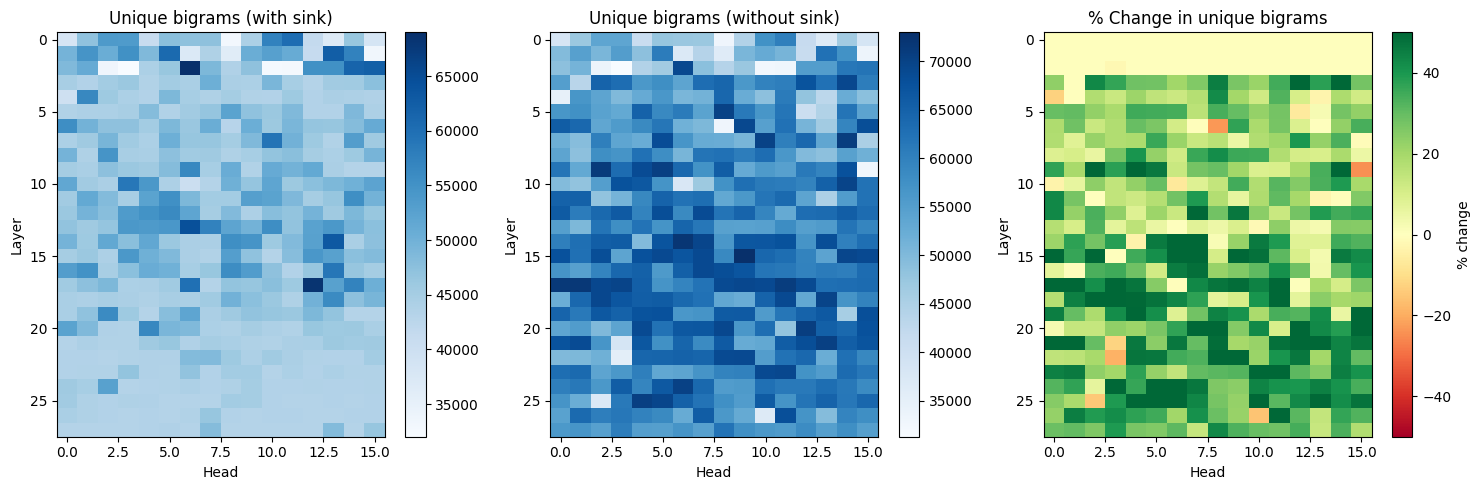


SINK MASKING ANALYSIS SUMMARY

--- Impact on Diversity ---
  Mean change in unique bigrams: +25.0%
  Layers with >20% increase: 19

--- Impact on Local Patterns ---
  Prev-token rate increased from 7.8% to 29.8%

--- Impact on Head Agreement ---
  Agreement dropped from 81.6% to 37.8%
  Interpretation: Sink was causing artificial agreement

--- Updated Recommendations ---
  1. MASK THE SINK: When using attention for engrams, always mask position 0
     This reveals more diverse, meaningful attention patterns
  2. Overlap decreased to 100.0% of sequential bigrams
     -> Attention bigrams are less aligned with local context
  3. Head agreement is now 37.8% (was 81.6%)
     -> Still viable for majority vote
  4. Implementation: After layer N attention, mask [:, 0] before argmax
     then use resulting bigram (attended_token, current_token) for embedding lookup


In [33]:
# Layer-wise change analysis and updated recommendations

# Unique bigrams per head: with vs without sink
unique_with = np.array([[len(attn_bigrams[l][h]) for h in range(NUM_HEADS)] for l in range(NUM_LAYERS)])
unique_without = np.array([[len(attn_bigrams_no_sink[l][h]) for h in range(NUM_HEADS)] for l in range(NUM_LAYERS)])
change_pct = (unique_without - unique_with) / unique_with * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(unique_with, aspect="auto", cmap="Blues")
axes[0].set_title("Unique bigrams (with sink)")
axes[0].set_xlabel("Head")
axes[0].set_ylabel("Layer")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(unique_without, aspect="auto", cmap="Blues")
axes[1].set_title("Unique bigrams (without sink)")
axes[1].set_xlabel("Head")
axes[1].set_ylabel("Layer")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(change_pct, aspect="auto", cmap="RdYlGn", vmin=-50, vmax=50)
axes[2].set_title("% Change in unique bigrams")
axes[2].set_xlabel("Head")
axes[2].set_ylabel("Layer")
plt.colorbar(im2, ax=axes[2], label="% change")

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 70)
print("SINK MASKING ANALYSIS SUMMARY")
print("=" * 70)

print("\n--- Impact on Diversity ---")
print(f"  Mean change in unique bigrams: {change_pct.mean():+.1f}%")
print(f"  Layers with >20% increase: {(change_pct.mean(axis=1) > 20).sum()}")

print("\n--- Impact on Local Patterns ---")
print(
    f"  Prev-token rate increased from {prev_rate_with_sink / total_with_sink:.1%} to {prev_rate_no_sink / total_no_sink:.1%}"
)

print("\n--- Impact on Head Agreement ---")
print(f"  Agreement dropped from {np.mean(all_agreements):.1%} to {np.mean(mean_agreement_no_sink):.1%}")
sink_caused_agreement = np.mean(mean_agreement_no_sink) < np.mean(all_agreements) * 0.8
print(
    f"  Interpretation: {'Sink was causing artificial agreement' if sink_caused_agreement else 'Heads genuinely agree'}"
)

print("\n--- Updated Recommendations ---")
overlap_increased = overlap_no_sink > overlap_with_sink
overlap_pct = overlap_no_sink / len(seq_bigram_set)
agreement_viable = np.mean(mean_agreement_no_sink) > 0.15
print("  1. MASK THE SINK: When using attention for engrams, always mask position 0")
print("     This reveals more diverse, meaningful attention patterns")
print(f"  2. Overlap {'increased' if overlap_increased else 'decreased'} to {overlap_pct:.1%} of sequential bigrams")
print(f"     -> Attention bigrams are {'more' if overlap_increased else 'less'} aligned with local context")
print(f"  3. Head agreement is now {np.mean(mean_agreement_no_sink):.1%} (was {np.mean(all_agreements):.1%})")
print(
    f"     -> {'Still viable for majority vote' if agreement_viable else 'Consider single-head or learned aggregation'}"
)
print("  4. Implementation: After layer N attention, mask [:, 0] before argmax")
print("     then use resulting bigram (attended_token, current_token) for embedding lookup")

## Compressed Tokenizer Analysis

The engram paper introduces a **vocabulary projection layer** that collapses semantically equivalent tokens (e.g., "Apple" vs " apple") into canonical IDs using NFKC normalization, lowercasing, accent stripping, etc. This achieves ~23% vocabulary reduction.

**Key Questions:**
1. How much does compression reduce unique bigrams (sequential)?
2. How much does compression reduce unique bigrams (attention-based)?
3. Do the top bigrams change after compression?
4. Does compression help with the attention sink issue (`. → .` patterns)?

In [34]:
# Cell 1: Import tokenizers library and define CompressedTokenizer
from tokenizers import Regex, normalizers


class CompressedTokenizer:
    def __init__(self, tokenizer_name_or_path):
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name_or_path, trust_remote_code=True)

        SENTINEL = "\ue000"
        self.normalizer = normalizers.Sequence(
            [
                normalizers.NFKC(),
                normalizers.NFD(),
                normalizers.StripAccents(),
                normalizers.Lowercase(),
                normalizers.Replace(Regex(r"[ \t\r\n]+"), " "),
                normalizers.Replace(Regex(r"^ $"), SENTINEL),
                normalizers.Strip(),
                normalizers.Replace(SENTINEL, " "),
            ]
        )

        self.lookup_table, self.num_new_token = self._build_lookup_table()

    def __len__(self):
        return self.num_new_token

    def _build_lookup_table(self):
        old2new = {}
        key2new = {}
        new_tokens = []

        vocab_size = len(self.tokenizer)
        for tid in range(vocab_size):
            text = self.tokenizer.decode([tid], skip_special_tokens=False)

            if "�" in text:
                key = self.tokenizer.convert_ids_to_tokens(tid)
            else:
                norm = self.normalizer.normalize_str(text)
                key = norm if norm else text

            nid = key2new.get(key)
            if nid is None:
                nid = len(new_tokens)
                key2new[key] = nid
                new_tokens.append(key)
            old2new[tid] = nid

        lookup = np.empty(vocab_size, dtype=np.int64)
        for tid in range(vocab_size):
            lookup[tid] = old2new[tid]

        return lookup, len(new_tokens)

    def compress(self, token_ids):
        """Map original token IDs to compressed IDs."""
        if isinstance(token_ids, np.ndarray):
            return self.lookup_table[token_ids]
        return [self.lookup_table[tid] for tid in token_ids]

    def decode_compressed(self, compressed_id):
        """Decode a compressed ID to its representative text (approximate)."""
        # Find first original token that maps to this compressed ID
        for tid, cid in enumerate(self.lookup_table):
            if cid == compressed_id:
                return self.tokenizer.decode([tid])
        return f"<unk:{compressed_id}>"

In [35]:
# Cell 2: Build compressed tokenizer and show stats
compressed_tokenizer = CompressedTokenizer(MODEL_NAME)

original_vocab_size = len(tokenizer.get_vocab())
compressed_vocab_size = len(compressed_tokenizer)
reduction_pct = (1 - compressed_vocab_size / original_vocab_size) * 100

print("=" * 60)
print("COMPRESSED TOKENIZER STATISTICS")
print("=" * 60)
print(f"Original vocab size:   {original_vocab_size:,}")
print(f"Compressed vocab size: {compressed_vocab_size:,}")
print(f"Reduction:             {reduction_pct:.1f}%")

# Show some example compressions
print("\nExample token compressions:")
examples = [" Apple", "apple", " APPLE", " apple", "Apple", "  apple"]
for ex in examples:
    token_ids = tokenizer.encode(ex, add_special_tokens=False)
    if token_ids:
        orig_id = token_ids[0]
        comp_id = compressed_tokenizer.lookup_table[orig_id]
        comp_text = compressed_tokenizer.decode_compressed(comp_id)
        print(f"  {repr(ex):>12} -> orig_id={orig_id:>6} -> comp_id={comp_id:>6} ({repr(comp_text)})")

COMPRESSED TOKENIZER STATISTICS
Original vocab size:   151,669
Compressed vocab size: 107,457
Reduction:             29.2%

Example token compressions:
      ' Apple' -> orig_id=  8162 -> comp_id=  5445 (' Apple')
       'apple' -> orig_id= 22377 -> comp_id=  5445 (' Apple')
      ' APPLE' -> orig_id= 90336 -> comp_id=  5445 (' Apple')
      ' apple' -> orig_id= 23268 -> comp_id=  5445 (' Apple')
       'Apple' -> orig_id= 26567 -> comp_id=  5445 (' Apple')
     '  apple' -> orig_id=   220 -> comp_id=   171 ('\t')


In [36]:
# Cell 3: Compressed Sequential Bigrams
compressed_tokens = compressed_tokenizer.compress(all_tokens)

# Rebuild sequential bigrams with compressed IDs
compressed_sequential_bigrams = Counter()
for i in range(1, len(compressed_tokens)):
    if all_tokens[i] == BOS_TOKEN or all_tokens[i - 1] == BOS_TOKEN:
        continue
    prev_compressed = compressed_tokens[i - 1]
    curr_compressed = compressed_tokens[i]
    compressed_sequential_bigrams[(prev_compressed, curr_compressed)] += 1

# Compare
raw_unique = len(sequential_bigrams)
compressed_unique = len(compressed_sequential_bigrams)
seq_reduction_pct = (1 - compressed_unique / raw_unique) * 100

print("=" * 60)
print("SEQUENTIAL BIGRAMS: RAW vs COMPRESSED")
print("=" * 60)
print(f"Raw unique bigrams:        {raw_unique:,}")
print(f"Compressed unique bigrams: {compressed_unique:,}")
print(f"Reduction:                 {seq_reduction_pct:.1f}%")

print("\nTop 15 COMPRESSED sequential bigrams:")
for (prev_id, curr_id), count in compressed_sequential_bigrams.most_common(15):
    prev_tok = compressed_tokenizer.decode_compressed(prev_id)
    curr_tok = compressed_tokenizer.decode_compressed(curr_id)
    print(f"  {repr(prev_tok):>15} -> {repr(curr_tok):<15}: {count:>6,}")

SEQUENTIAL BIGRAMS: RAW vs COMPRESSED
Raw unique bigrams:        53,562
Compressed unique bigrams: 50,941
Reduction:                 4.9%

Top 15 COMPRESSED sequential bigrams:
            ' of' -> ' the'         :    393
             'in' -> ' the'         :    326
              ',' -> ' and'         :    316
             '\t' -> '2'            :    295
             '\t' -> '1'            :    281
              '.' -> ' the'         :    274
              '2' -> '0'            :    266
              '0' -> '0'            :    168
              ',' -> '\t'           :    157
              ',' -> ' the'         :    145
            ' to' -> ' the'         :    132
              '0' -> '1'            :    129
              '1' -> '9'            :    128
              '.' -> 'in'           :    118
              '.' -> ' this'        :    116


In [37]:
# Cell 4: Compressed Attention Bigrams
# Map existing attention bigrams through compression

compressed_attn_bigrams = [[Counter() for _ in range(NUM_HEADS)] for _ in range(NUM_LAYERS)]
compressed_all_attn_bigrams = Counter()

for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        for (attended_id, curr_id), count in attn_bigrams[layer][head].items():
            attended_compressed = compressed_tokenizer.lookup_table[attended_id]
            curr_compressed = compressed_tokenizer.lookup_table[curr_id]
            compressed_attn_bigrams[layer][head][(attended_compressed, curr_compressed)] += count
            compressed_all_attn_bigrams[(attended_compressed, curr_compressed)] += count

# Compare aggregated attention bigrams
raw_attn_unique = len(all_attn_bigrams)
compressed_attn_unique = len(compressed_all_attn_bigrams)
attn_reduction_pct = (1 - compressed_attn_unique / raw_attn_unique) * 100

print("=" * 60)
print("ATTENTION BIGRAMS (AGGREGATED): RAW vs COMPRESSED")
print("=" * 60)
print(f"Raw unique bigrams:        {raw_attn_unique:,}")
print(f"Compressed unique bigrams: {compressed_attn_unique:,}")
print(f"Reduction:                 {attn_reduction_pct:.1f}%")

print("\nTop 15 COMPRESSED attention bigrams:")
for (attended_id, curr_id), count in compressed_all_attn_bigrams.most_common(15):
    attended_tok = compressed_tokenizer.decode_compressed(attended_id)
    curr_tok = compressed_tokenizer.decode_compressed(curr_id)
    print(f"  {repr(attended_tok):>15} -> {repr(curr_tok):<15}: {count:>6,}")

ATTENTION BIGRAMS (AGGREGATED): RAW vs COMPRESSED
Raw unique bigrams:        809,689
Compressed unique bigrams: 707,995
Reduction:                 12.6%

Top 15 COMPRESSED attention bigrams:
              '.' -> '.'            : 159,305
              ',' -> ','            : 121,597
              '.' -> ','            : 105,601
              ',' -> ' the'         : 83,914
              ',' -> '.'            : 78,654
              '.' -> ' the'         : 69,406
              ',' -> ' and'         : 64,280
           ' and' -> ','            : 59,301
              '.' -> ' and'         : 53,561
            ' of' -> ' the'         : 50,436
           ' and' -> '.'            : 46,827
           ' and' -> ' and'         : 46,643
           ' the' -> ' the'         : 45,066
           ' and' -> ' the'         : 40,897
            ' to' -> ' the'         : 40,420


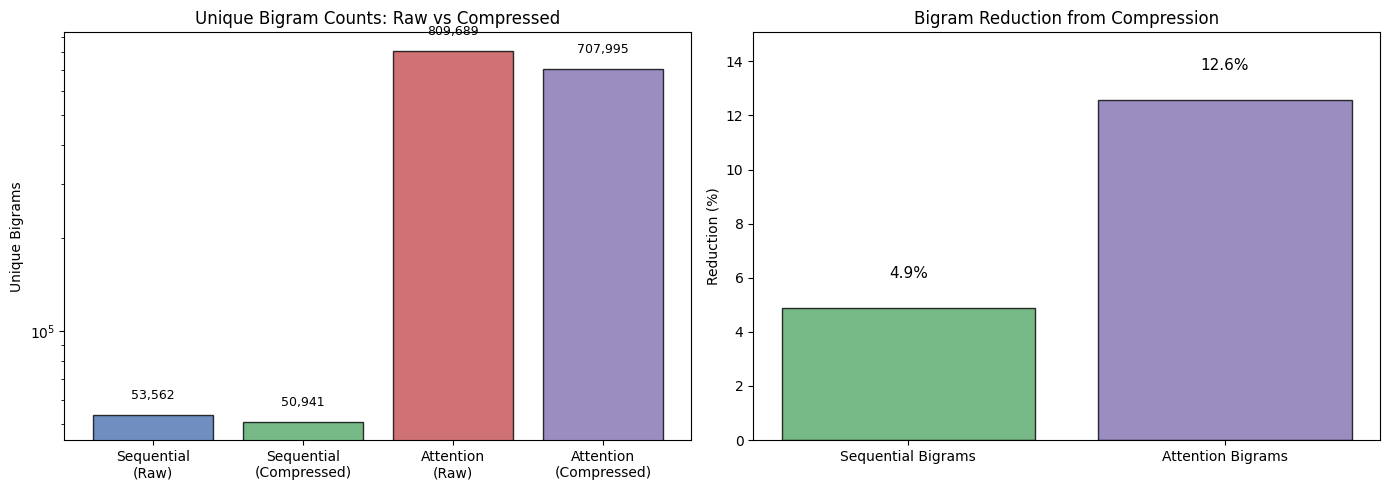


Summary:
  Vocabulary compression: 29.2%
  Sequential bigram reduction: 4.9%
  Attention bigram reduction: 12.6%


In [38]:
# Cell 5: Comparison Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: unique bigram counts
categories = ["Sequential\n(Raw)", "Sequential\n(Compressed)", "Attention\n(Raw)", "Attention\n(Compressed)"]
counts = [raw_unique, compressed_unique, raw_attn_unique, compressed_attn_unique]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

ax1 = axes[0]
bars = ax1.bar(categories, counts, color=colors, edgecolor="black", alpha=0.8)
ax1.set_ylabel("Unique Bigrams")
ax1.set_title("Unique Bigram Counts: Raw vs Compressed")
ax1.set_yscale("log")
for bar, count in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.1, f"{count:,}", ha="center", va="bottom", fontsize=9
    )

# Bar chart: reduction percentages
ax2 = axes[1]
reductions = [seq_reduction_pct, attn_reduction_pct]
reduction_labels = ["Sequential Bigrams", "Attention Bigrams"]
bars2 = ax2.bar(reduction_labels, reductions, color=["#55A868", "#8172B2"], edgecolor="black", alpha=0.8)
ax2.set_ylabel("Reduction (%)")
ax2.set_title("Bigram Reduction from Compression")
ax2.set_ylim(0, max(reductions) * 1.2)
for bar, pct in zip(bars2, reductions):
    ax2.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{pct:.1f}%", ha="center", va="bottom", fontsize=11
    )

plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"  Vocabulary compression: {reduction_pct:.1f}%")
print(f"  Sequential bigram reduction: {seq_reduction_pct:.1f}%")
print(f"  Attention bigram reduction: {attn_reduction_pct:.1f}%")

In [39]:
# Cell 6: Analysis of Compression Impact on Attention Sinks
print("=" * 60)
print("COMPRESSION IMPACT ON ATTENTION SINKS")
print("=" * 60)

# Find punctuation-related bigrams in raw vs compressed
punctuation_tokens_raw = set()
for token_text, token_id in tokenizer.get_vocab().items():
    decoded = tokenizer.decode([token_id])
    if decoded.strip() in [".", ",", "!", "?", ";", ":", "-", "(", ")", "[", "]"]:
        punctuation_tokens_raw.add(token_id)

# Count sink patterns (punctuation -> anything) in raw
raw_sink_count = 0
raw_sink_patterns = Counter()
for (attended, curr), count in all_attn_bigrams.items():
    if attended in punctuation_tokens_raw:
        raw_sink_count += count
        attended_tok = tokenizer.decode([attended])
        raw_sink_patterns[attended_tok] += count

# Find punctuation in compressed vocab by checking what raw punctuation tokens map to
punctuation_tokens_compressed = set()
for raw_id in punctuation_tokens_raw:
    punctuation_tokens_compressed.add(int(compressed_tokenizer.lookup_table[raw_id]))

# Count sink patterns in compressed
compressed_sink_count = 0
compressed_sink_patterns = Counter()
for (attended, curr), count in compressed_all_attn_bigrams.items():
    if attended in punctuation_tokens_compressed:
        compressed_sink_count += count
        attended_tok = compressed_tokenizer.decode_compressed(attended)
        compressed_sink_patterns[attended_tok] += count

total_raw = sum(all_attn_bigrams.values())
total_compressed = sum(compressed_all_attn_bigrams.values())

print("\nPunctuation as attention source (sink behavior):")
print(f"  Raw:        {raw_sink_count:,} / {total_raw:,} ({100 * raw_sink_count / total_raw:.1f}%)")
print(
    f"  Compressed: {compressed_sink_count:,} / {total_compressed:,} ({100 * compressed_sink_count / total_compressed:.1f}%)"
)

print("\nTop punctuation sinks (raw):")
for tok, count in raw_sink_patterns.most_common(5):
    print(f"  {repr(tok):>10}: {count:,} ({100 * count / total_raw:.1f}%)")

print("\nTop punctuation sinks (compressed):")
for tok, count in compressed_sink_patterns.most_common(5):
    print(f"  {repr(tok):>10}: {count:,} ({100 * count / total_compressed:.1f}%)")

# Specific analysis: Does ". -> ." collapse with other patterns?
print("\n" + "-" * 60)
print("DOES COMPRESSION COLLAPSE PERIOD SINKS?")
print("-" * 60)

# Find all raw tokens that compress to the same as "."
period_tokens = tokenizer.encode(".", add_special_tokens=False)
if period_tokens:
    period_orig_id = period_tokens[0]
    period_compressed_id = int(compressed_tokenizer.lookup_table[period_orig_id])

    # Find all original tokens that map to this compressed ID
    collapsed_to_period = []
    for tid in range(len(compressed_tokenizer.lookup_table)):
        if compressed_tokenizer.lookup_table[tid] == period_compressed_id:
            collapsed_to_period.append(tokenizer.decode([tid]))

    print(f"Tokens collapsed to same ID as '.' ({period_compressed_id}):")
    print(f"  {collapsed_to_period[:20]}")  # Show first 20
    if len(collapsed_to_period) > 20:
        print(f"  ... and {len(collapsed_to_period) - 20} more")

COMPRESSION IMPACT ON ATTENTION SINKS

Punctuation as attention source (sink behavior):
  Raw:        4,878,911 / 38,829,952 (12.6%)
  Compressed: 4,878,911 / 38,829,952 (12.6%)

Top punctuation sinks (raw):
         ',': 1,982,477 (5.1%)
         '.': 1,153,203 (3.0%)
       '.\n': 906,352 (2.3%)
         ':': 225,366 (0.6%)
         '-': 224,378 (0.6%)

Top punctuation sinks (compressed):
         '.': 2,073,661 (5.3%)
         ',': 1,988,225 (5.1%)
         ':': 250,039 (0.6%)
         '-': 226,174 (0.6%)
         ';': 192,728 (0.5%)

------------------------------------------------------------
DOES COMPRESSION COLLAPSE PERIOD SINKS?
------------------------------------------------------------
Tokens collapsed to same ID as '.' (13):
  ['.', '.\n\n', '.\n', ' .', '.\n\n\n\n', '.\r\n', '.\n\n\n', ' .\n\n', '.\n\n\n\n\n\n', ' .\n', '.\r\n\r\n', '.\n\n\n\n\n\n\n\n', '.\n\n\n\n\n\n\n\n\n\n', '．', ' .\n\n\n\n', '.\n\n\n\n\n', ' .\r\n', '.\n\n\n\n\n\n\n\n\n\n\n\n', '․']
